## Analyse gridded contrail forcing simulations based on CoCiP for 2019

**Goal:** Evaluate **gridded forcing** from a newer 2019 simulation re-run by ICL with an updated version of pycontrails (v0.54.8). It has ~20% lower total energy forcing than the original publication and does not account for vPM activations. 

**Analyses:**

* File availability and statistics of forcing datasets
    - I used to approaches to analyse the data
        1. Convert tabular parquet files to hourly grid-based netcdf files + sum hourly grid-based files to get hourly, monthly and annual averages
        2. Directly sum parquet files for different FIRs to get hourly, monthly and annual statistics by FIR  - this method retains more of the original data fields since it is more memory efficient. At the same time, I lose all spatial information. 
    - Both approaches agree numerically
* Maps of flight distance, warming and contrails per flight
    - Use netcdf files and aggregate using xarray
* Forcing per **flight distance**, **hour**, **month**, **flight level**, and **FIR**
    - User parquet files with the exception of forcing per flight level
    - Aggregate using pandas


## Setup

In [9]:

global_flights            = 40.2e6 # https://acp.copernicus.org/articles/24/725/2024/
global_area               = 510072000 # km^2
global_dist               = 60854010000000.0 # m
global_warming            = 7.716292165828328e+20 # J
global_warming_per_dist   = global_warming / global_dist # J/m

european_dist             = 12966068000000.0
european_warming          = 2.3044921243225856e+20
european_warming_per_dist = european_warming / european_dist # J/m


warming_normalisation          = european_warming
dist_normalisation             = european_dist
warming_per_dist_normalisation = warming_normalisation / dist_normalisation

## 0. Data availability

In [ ]:
import os
import pandas as pd
from datetime import datetime

# --- CONFIG ---
# Path to your folder containing .pq files
FOLDER_PATH = "./"
# Path to the output CSV
OUTPUT_CSV = "forcing_pq_file_availability.csv"

# --- MAIN SCRIPT ---
data = []

# List all files in the directory
for filename in os.listdir(FOLDER_PATH):
    if filename.endswith(".pq"):
        filepath = os.path.join(FOLDER_PATH, filename)
        # Extract date from filename (assuming format YYYYMMDD.pq)
        try:
            date_str = filename.replace(".pq", "")
            date = datetime.strptime(date_str, "%Y%m%d").date()
        except ValueError:
            # Skip any files not matching the pattern
            continue
        
        availability = os.path.exists(filepath)
        data.append({
            "filename": filename,
            "date": date,
            "availability": availability
        })

# Convert to DataFrame
df = pd.DataFrame(data)

# Sort by date
df = df.sort_values(by="date")

# Save to CSV
df.to_csv(OUTPUT_CSV, index=False)

print(f"CSV written to {OUTPUT_CSV} with {len(df)} entries.")


![image.png](figures\2_forcing\forcing_1_pq_file_availability@2x.png)

## 1. Approach 1: Convert parquet files to netcdf and then sum

### Convert parquet to netcdf

- Adapt convert_parquet_to_netcdf.py to gridded forcing data and only keep fields relevant for this analysis
- Convert to 4 byte floating point numbers to save memory - this entails a loss of accuracy that I deem acceptable for this type of analysis

In [ ]:
"""
Convert contrail parquet data to hourly NetCDF (4D: lon-lat-alt-time).
"""

import warnings
import numpy as np
import pandas as pd
import xarray as xr
import sys
from tqdm import tqdm
import os 

# ----------- USER INPUTS ----------- #

FOLDER_PATH = "./"        # Folder with daily parquet files
OUTPUT_PATH = "cdf/"      # Folder to save hourly netcdf files

# CLI arguments: start and end date (inclusive)
if len(sys.argv) >= 3:
    DATE_START = sys.argv[1]
    DATE_END = sys.argv[2]
else:
    print("Usage: python script.py YYYY-MM-DD YYYY-MM-DD")
    sys.exit(1)

TEMPORAL_RES_H = 1  # 1-hour resolution

# Altitude dimension (m)
ALTITUDE_BOUNDS_M = (6000.0, 15000.0)
ALTITUDE_RES_M = 304.8 # 1000 ft = 10 flight levels

# Longitude-latitude dimension (degrees)
SPATIAL_BBOX = (-180.0, -90.0, 180.0, 90.0)
SPATIAL_GRID_RES = 0.25

# ----------- FUNCTIONS ----------- #

def _agg_to_grid(df_res, agg_map, lon_coords, lat_coords, alt_coords):
    shape = lon_coords.size, lat_coords.size, alt_coords.size

    # Perform a binary search on a sorted array a to find the indices where elements of v should be inserted to maintain the order of a.
    idx_lon = np.searchsorted(lon_coords, df_res["longitude"])
    idx_lat = np.searchsorted(lat_coords, df_res["latitude"])
    idx_alt = np.searchsorted(alt_coords, df_res["altitude"])

    # This gives an edge-centered grid!
    # If your longitude grid coordinates are: lon_coords = [0.0, 0.25, 0.50, 0.75, 1.0]
    # And your data points have longitudes: df_res["longitude"] = [0.1, 0.5, 0.99, 1.2]
    # idx_lon = np.searchsorted(lon_coords, df_res["longitude"]) would return: [1, 2, 4, 5]
    # Groupby the returned indices
    # So, lon = 0.25 will contain all longitudes from (0, 0.25]
    # This is actually slightly different from the standard xarray definition. 

    df_agg = df_res.groupby([idx_lon, idx_lat, idx_alt]).agg(agg_map)
    i0, i1, i2 = df_agg.index.get_level_values(0), df_agg.index.get_level_values(1), df_agg.index.get_level_values(2)
    ds = xr.Dataset(coords={"longitude": lon_coords, "latitude": lat_coords, "altitude": alt_coords})

    for name, col in df_agg.items():
        arr = np.zeros(shape, dtype=np.float32)
        arr[i0, i1, i2] = col.astype(np.float32)
        ds[name] = (("longitude", "latitude", "altitude"), arr)

    return ds


def _convert_daily_to_hourly(date: pd.Timestamp):
    date_str = date.strftime("%Y%m%d")
    file_path = f"{FOLDER_PATH}/{date_str}.pq"
    df_res = pd.read_parquet(file_path)

    # Downcast floats
    float_cols = df_res.select_dtypes(include=['float64']).columns
    df_res[float_cols] = df_res[float_cols].astype('float32')

    df_res['new_contrail_length'] = df_res['new_contrail_length'].fillna(0)

    # Filter by spatial and altitude bounds
    west, south, east, north = SPATIAL_BBOX
    df_res = df_res[
        df_res["longitude"].between(west, east)
        & df_res["latitude"].between(south, north)
        & df_res["altitude"].between(*ALTITUDE_BOUNDS_M)
    ].copy()

    # Coordinates
    lon_coords = np.arange(west, east + 0.01, SPATIAL_GRID_RES)
    lat_coords = np.arange(south, north + 0.01, SPATIAL_GRID_RES)
    alt_coords = np.arange(ALTITUDE_BOUNDS_M[0], ALTITUDE_BOUNDS_M[1] + ALTITUDE_RES_M, ALTITUDE_RES_M)
    df_res["hour"] = df_res["hour"].round().astype(int)

    # Time slices
    time_slices = np.arange(0, 25, TEMPORAL_RES_H)
    for t in range(len(time_slices) - 1):
        h_start, h_end = time_slices[t], time_slices[t + 1]
        filt = df_res["hour"].between(h_start, h_end, inclusive="left")
        df_hour = df_res[filt].copy()
        if len(df_hour) == 0:
            continue
        _grid_one_hour(date, h_start, h_end, df_hour, lon_coords, lat_coords, alt_coords)


def _grid_one_hour(date, h_start, h_end, df_hour, lon_coords, lat_coords, alt_coords):

    # Build expected output filename early
    t_start_str = date.strftime("%Y%m%d")
    t_end_str = f"{h_end:02d}"
    output_file = f"{OUTPUT_PATH}/{t_start_str}-{h_start:02d}-{t_end_str}-contrail.nc"

    # Aggregations
    agg_map = {
        'total_flight_dist': 'sum',
        'contrail_ef_overlap_initial_loc': 'sum',
    }
    ds_agg = _agg_to_grid(df_hour, agg_map, lon_coords, lat_coords, alt_coords)

    # Merge hourly datasets
    ds = xr.Dataset(
        data_vars=dict(
            total_flight_dist=(["longitude", "latitude", "altitude"], ds_agg["total_flight_dist"].values / 1000),
            ef_initial_loc_overlap=(["longitude", "latitude", "altitude"], ds_agg["contrail_ef_overlap_initial_loc"].values),
        ),
        coords=dict(longitude=lon_coords, latitude=lat_coords, altitude=alt_coords)
    )

    # Add time dimension
    t_mid = date + pd.Timedelta(hours=h_start + TEMPORAL_RES_H / 2)
    ds = ds.expand_dims().assign_coords({"time": t_mid})

    # Compression and saving
    t_start_str = date.strftime("%Y%m%d")
    t_end_str = f"{h_end:02d}"
    output_file = f"{OUTPUT_PATH}/{t_start_str}-{h_start:02d}-{t_end_str}-contrail.nc"


    comp = dict(zlib=True, complevel=4, dtype='float32')
    encoding = {var: comp for var in ds.data_vars}
    ds.to_netcdf(output_file, encoding=encoding)
    print(f"✅ Saved {output_file}")


def main():
    dates = pd.date_range(DATE_START, DATE_END, freq="1D")
    for date in tqdm(dates, desc="Processing days"):
        _convert_daily_to_hourly(date)


if __name__ == "__main__":
    main()


### Check conversion of netcdf files
I am checking this since the netcdf file writer often fails (writes files only containing zeros) and I needed to run it several times for all files to be written correctly (hopefully). 


In [ ]:
import os
import re
import pandas as pd
from datetime import datetime

# --- CONFIG ---
FOLDER_PATH = "/path/to/your/cdf/folder"
OUTPUT_CSV = "daily_nc_availability.csv"

# --- MAIN SCRIPT ---
pattern = re.compile(r"(\d{8})-(\d{2})-(\d{2})-contrail\.nc$")

# Dictionary to store available hours per day
# If we have all the hourly info, the end result should be a dict with 365 entries and 24 elements in the set for each entry.
availability = {}

for filename in os.listdir(FOLDER_PATH):
    if filename.endswith(".nc"):
        match = pattern.search(filename)
        if not match:
            continue

        date_str, hour_start, _ = match.groups()
        date = datetime.strptime(date_str, "%Y%m%d").date()

        # Record availability for that hour
        # Set empty default set for each date and then add hours
        availability.setdefault(date, set()).add(int(hour_start))

# Build a list of rows for the CSV
rows = []
for date, hours in sorted(availability.items()):
    total_hours_available = len(hours)
    share = total_hours_available / 24  # Share of day covered
    rows.append({
        "date": date,
        "filename_pattern": f"{date.strftime('%Y%m%d')}-*-*-contrail.nc",
        "availability_share": round(share, 3)
    })

# Convert to DataFrame and save
df = pd.DataFrame(rows)
df.to_csv(OUTPUT_CSV, index=False)

print(f"✅ Wrote {OUTPUT_CSV} with {len(df)} days of data.")


![image.png](figures\2_forcing\forcing_2_netcdf_file_availability@2x.png)

### Sum netcdf files
- sum all numerical variables in netcdf input files and write to outfile with compression
- make sure that grids coincide

In [ ]:
import sys
import xarray as xr
import os

OUTFILE = sys.argv[1]
FILES = sys.argv[2:]

def aggregate(files, outfile):
    running_sum = None
    for f in files:
        try:
            ds = xr.open_dataset(f, engine="netcdf4", decode_timedelta=False)
            print(f"Processing {f} with vars: {ds.data_vars}")
            ds = ds.fillna(0).squeeze(drop=True)
            ds = ds.drop_vars("hour", errors="ignore")
            if running_sum is None:
                running_sum = ds.astype("float32")
            else:
                running_sum = running_sum + ds.astype("float32")
        except Exception as e:
            print(f"⚠️ Error reading {f}: {e}")
        finally:
             ds.close()

    if running_sum is not None:
        encoding = {
            var: {"zlib": True, "complevel": 4, "dtype": "float32"}
            for var in running_sum.data_vars
        }
        running_sum.to_netcdf(outfile, encoding=encoding)
        print(f"✅ Saved {outfile}")

if __name__ == "__main__":
    if not FILES:
        print("No files given.")
        sys.exit(1)
    aggregate(FILES, OUTFILE)


### Run multi-threated summation of netcdf files

- read hourly netcdf files for the entire year and sum them by hour, month and finally year

In [ ]:
#!/usr/bin/env python3
import os
import subprocess
from datetime import datetime
from concurrent.futures import ProcessPoolExecutor, as_completed

# ================= CONFIG ==================
INDIR = "cdf/"
OUTDIR = "aggregated"
os.makedirs(OUTDIR, exist_ok=True)
N_WORKERS = 12  # Adjust for your CPU / cluster
# ===========================================

def parse_time(fname):
    """Parse filenames like 20190101-11-12-gaia.nc -> datetime(2019,1,1,11)."""
    base = os.path.basename(fname).replace(".nc", "")
    parts = base.split("-")
    if len(parts) >= 4 and parts[-1] == "contrail":
        date_str = parts[0]  # 20190101
        hour_str = parts[1]  # 11 (start hour)
        dt = datetime.strptime(f"{date_str}{hour_str}", "%Y%m%d%H")
        return dt
    raise ValueError(f"Unexpected filename format: {fname}")

def call_worker(outpath, files):
    """Run the external aggregation script."""
    if not files:
        print(f"⚠️ No input files for {outpath}, skipping.")
        return None
    
    try:
        subprocess.run(
            ["python", "aggregate.py", outpath] + files,
            check=True
        )
        return outpath
    except subprocess.CalledProcessError as e:
        print(f"❌ Failed to aggregate {outpath}: {e}")
        return None

def launch_parallel_aggregate(jobs, desc):
    """
    Run a batch of call_worker tasks in parallel.
    jobs: list of tuples (outpath, files)
    desc: str, description for logging
    Returns: list of successful outpaths
    """
    results = []
    if not jobs:
        print(f"⚠️ No jobs to run for {desc}.")
        return results

    print(f"🚀 Launching {len(jobs)} {desc} jobs using {N_WORKERS} workers...")
    #for out, flist in jobs:
    #    call_worker(out, flist)
    with ProcessPoolExecutor(max_workers=N_WORKERS) as executor:
        future_map = {executor.submit(call_worker, out, flist): out for out, flist in jobs}
        for fut in as_completed(future_map):
            outpath = future_map[fut]
            res = fut.result()
            if res:
                results.append(res)
                print(f"✅ Done: {os.path.basename(outpath)}")
            else:
                print(f"⚠️ Skipped or failed: {os.path.basename(outpath)}")
    print(f"✅ Completed all {desc} jobs.\n")
    return results

def main():
    # === STEP 1: Gather input files ===
    nc_files = sorted([
        os.path.join(INDIR, f)
        for f in os.listdir(INDIR)
        if f.endswith(".nc") and "-contrail" in f
    ])
    print(f"📦 Found {len(nc_files)} input files.")

    print("Processing hourly sums per month")
    # === STEP 2: Hourly sums per month ===
    hourly_jobs = []
    for month in range(1, 13):
        for hour in range(0, 24):
            files = [f for f in nc_files if parse_time(f).month == month and parse_time(f).hour == hour]
            if not files:
                continue
            outname = f"hourly_sum_m{month:02d}_h{hour:02d}.nc"
            outpath = os.path.join(OUTDIR, outname)
            hourly_jobs.append((outpath, files))

    print(f"Calling launch_parallel_aggregate with {len(hourly_jobs)}")
    hourly_by_month_files = {}
    hourly_results =  [outpath for outpath, _ in hourly_jobs]# launch_parallel_aggregate(hourly_jobs, "hourly (month-hour)") #
    for outpath in hourly_results:
        name = os.path.basename(outpath)
        parts = name.replace("hourly_sum_m", "").replace(".nc", "").split("_h")
        month = int(parts[0])
        hour = int(parts[1])
        hourly_by_month_files[(month, hour)] = outpath

    print("Computing monthly sums!")

    # === STEP 3: Monthly sums ===
    monthly_jobs = []
    for month in range(1, 13):
        files = [hourly_by_month_files[(month, h)] for h in range(24) if (month, h) in hourly_by_month_files]
        if not files:
            continue
        outname = f"monthly_sum_{month:02d}.nc"
        outpath = os.path.join(OUTDIR, outname)
        monthly_jobs.append((outpath, files))

    monthly_results = launch_parallel_aggregate(monthly_jobs, "monthly")
    monthly_files = {int(os.path.basename(f).split("_")[2].split(".")[0]): f for f in monthly_results}


    # === STEP 4: Annual sum ===
    if monthly_files:
        annual_out = os.path.join(OUTDIR, "annual_sum.nc")
        print(f"→ Aggregating annual sum from {len(monthly_files)} monthly files...")
        call_worker(annual_out, list(monthly_files.values()))
    else:
        print("⚠️ Skipping annual sum — no monthly files found.")


    # === STEP 5: Hourly sums across all months ===
    hourly_across_jobs = []
    for hour in range(0, 24):
        files = [hourly_by_month_files[(m, hour)] for m in range(1, 13) if (m, hour) in hourly_by_month_files]
        if not files:
            continue
        outname = f"annual_hourly_sum_{hour:02d}.nc"
        outpath = os.path.join(OUTDIR, outname)
        hourly_across_jobs.append((outpath, files))

    launch_parallel_aggregate(hourly_across_jobs, "hourly-across-months")

    print("🎉 All aggregations complete.")

if __name__ == "__main__":
    main()

## 2. Approach 2: Compute statistics directly from parquet files

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
import regionmask
import json, topojson
import glob, re
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import datetime

# ---------------------------------------
# CONFIGURATION
# ---------------------------------------
COLS_SUM = [
    "total_flight_dist", 
    "contrail_ef_initial_loc",
    "contrail_ef_overlap_initial_loc", 
    "new_contrail_length", 
    "total_contrail_length", 
    "tau_contrail_area", 
    "mean_contrail_age", 
    "contrail_ef", 
    "contrail_ef_sw", 
    "contrail_ef_lw", 
    "contrail_ef_overlap", 
    "contrail_ef_sw_overlap", 
    "contrail_ef_lw_overlap"
]


def build_regionmask():
    """Builds a combined regionmask from FIRs."""

    
    # Load the combined GeoDataFrame
    gdf_combined = gpd.read_file("airspaces.geojson").set_crs(epsg=4326)

    # Build the region mask
    combined_mask = regionmask.Regions(
        outlines=gdf_combined.geometry.values,
        names=gdf_combined["name"].tolist(),
        abbrevs=gdf_combined["name"].tolist()
    )

    return combined_mask


def process_file(file, mask):
    """Processes a single parquet file for all FIR/regions."""
    import pandas as pd
    import geopandas as gpd
    from shapely.geometry import Point
    import re

    fname = Path(file).stem
    m = re.search(r"(\d{8})", fname)
    if m: 
        date = pd.Timestamp(m.group(1))
    else:
        raise ValueError(f"Unsupported filename: {fname} when processing single parquet file for all FIR/regions")

    df = pd.read_parquet(file).fillna(0)
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["longitude"], df["latitude"]), crs="EPSG:4326")

    results = []
    for region_id, region_name in enumerate(mask.names):
        print("Processing: ", region_name)
        geom = mask[region_id].polygon
        minx, miny, maxx, maxy = geom.bounds
        subset = gdf.cx[minx:maxx, miny:maxy]
        subset = subset[subset.geometry.within(geom)]
        if subset.empty:
            continue

        df_hourly = subset.groupby("hour")[COLS_SUM].sum(min_count=1).reset_index()
        df_hourly["timestamp"] = [date + pd.Timedelta(hours=int(h)) for h in df_hourly["hour"]]
        df_hourly["region"] = region_name
        df_hourly["file"] = Path(file).name
        results.append(df_hourly)

    return pd.concat(results, ignore_index=True) if results else None


def main():
    """Main entry point for multiprocessing FIR analysis."""
    folder_path = "./"
    pq_files = sorted(glob.glob(f"{folder_path}/*.pq"))

    n_workers = 4  # Adjust to CPU cores

    if not pq_files:
        print("❌ No parquet files found!")
        return

    print(f"Found {len(pq_files)} parquet files")
    mask = build_regionmask()

    results = []
    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(process_file, f, mask): f for f in pq_files}
        for fut in tqdm(as_completed(futures), total=len(futures), desc="Processing files"):
            try:
                df_res = fut.result()
                if df_res is not None:
                    results.append(df_res)
            except Exception as e:
                print(f"⚠️ Error processing {futures[fut]}: {e}")

    if not results:
        print("❌ No data processed!")
        return

    df_all = pd.concat(results, ignore_index=True)
    output_path = Path("hourly_totals_by_region.pq")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    df_all.to_parquet(output_path, index=False)
    print(f"✅ Multiprocessing complete. Results saved to {output_path}")


if __name__ == "__main__":
    main()


In [2]:
import pandas as pd
from pathlib import Path

# ---------------------------------------
# CONFIGURATION
# ---------------------------------------
COLS_SUM = [
    "total_flight_dist", 
    "contrail_ef_initial_loc",
    "contrail_ef_overlap_initial_loc", 
    "new_contrail_length", 
    "total_contrail_length", 
    "tau_contrail_area", 
    "mean_contrail_age", 
    "contrail_ef", 
    "contrail_ef_sw", 
    "contrail_ef_lw", 
    "contrail_ef_overlap", 
    "contrail_ef_sw_overlap", 
    "contrail_ef_lw_overlap"
]


def aggregate_all_parquet_files_streaming(pq_files):
    """
    Memory-safe global temporal aggregation.
    Files are processed one by one; no concatenation in RAM.
    
    Result: global_temporal_sum.pq
    Aggregation: sum over identical (longitude, latitude, altitude)
    """

    from collections import defaultdict
    import numpy as np

    # Accumulator: keys = (lon, lat, alt), values = COLS_SUM values
    acc = defaultdict(lambda: np.zeros(len(COLS_SUM), dtype=float))

    for f in pq_files:
        print(f"Adding {f}...")
        df = pd.read_parquet(f).fillna(0)

        # Group file internally first (cheap)
        group_cols = ["longitude", "latitude", "altitude"]
        df_g = df.groupby(group_cols)[COLS_SUM].sum(min_count=1)

        # Update accumulator
        for (lon, lat, alt), row in df_g.iterrows():
            acc[(lon, lat, alt)] += row.values

    # Convert accumulator to DataFrame
    records = []
    for (lon, lat, alt), sums in acc.items():
        rec = {
            "longitude": lon,
            "latitude": lat,
            "altitude": alt,
            **{col: sums[i] for i, col in enumerate(COLS_SUM)}
        }
        records.append(rec)

    df_out = pd.DataFrame(records)

    out = Path("data/gridded_forcing/global_temporal_sum.pq")
    df_out.to_parquet(out, index=False)
    print(f"✅ Streaming temporal sum written to {out}")

    return df_out


In [3]:
import glob 
folder_path = "D:/GriddedForcing/data-sharing-transport-environment/"
pq_files = sorted(glob.glob(f"{folder_path}/*.pq"))

n_workers = 4  # Adjust to CPU cores

if not pq_files:
    print("❌ No parquet files found!")

In [27]:
pq_files

['D:/GriddedForcing/data-sharing-transport-environment\\20190101.pq',
 'D:/GriddedForcing/data-sharing-transport-environment\\20190102.pq',
 'D:/GriddedForcing/data-sharing-transport-environment\\20190103.pq',
 'D:/GriddedForcing/data-sharing-transport-environment\\20190104.pq',
 'D:/GriddedForcing/data-sharing-transport-environment\\20190105.pq',
 'D:/GriddedForcing/data-sharing-transport-environment\\20190106.pq',
 'D:/GriddedForcing/data-sharing-transport-environment\\20190107.pq',
 'D:/GriddedForcing/data-sharing-transport-environment\\20190108.pq',
 'D:/GriddedForcing/data-sharing-transport-environment\\20190109.pq',
 'D:/GriddedForcing/data-sharing-transport-environment\\20190110.pq',
 'D:/GriddedForcing/data-sharing-transport-environment\\20190111.pq',
 'D:/GriddedForcing/data-sharing-transport-environment\\20190112.pq',
 'D:/GriddedForcing/data-sharing-transport-environment\\20190113.pq',
 'D:/GriddedForcing/data-sharing-transport-environment\\20190114.pq',
 'D:/GriddedForcing/

In [ ]:
aggregate_all_parquet_files_streaming(pq_files)

## 3. Global statistics (used in report)

Compute forcing statistics and compare with results in Teoh et al. 2024 to check whether the conversions/summations went well. 

### Compute statistics using the netcdf approach 1

In [5]:
import xarray as xr 
import pandas as pd 
ds = xr.open_dataset("data/gridded_forcing/annual_sum.nc")
ds["forcing_per_dist"] = ds["ef_initial_loc_overlap"] / ds["total_flight_dist"]



# These definitions follow the bounding boxes in Teoh et al.'s paper (except for Eurocontrol)
regions = {
    "Global": {"lon_min": -180, "lon_max": 180, "lat_min": -90, "lat_max": 90},
    "USA": {"lon_min": -126, "lon_max": -66, "lat_min": 23, "lat_max": 50},
    "Europe": {"lon_min": -12, "lon_max": 20, "lat_min": 35, "lat_max": 60},
    "Eurocontrol": {"lon_min": -30.0, "lon_max": 45.0, "lat_min": 25.0, "lat_max": 72.0},
    "Eurocontrol + North Atlantic": {"lon_min": -70.0, "lon_max": 45.0, "lat_min": 25.0, "lat_max": 72.0},
    "East_Asia": {"lon_min": 103, "lon_max": 150, "lat_min": 15, "lat_max": 48},
    "Southeast_Asia": {"lon_min": 87.5, "lon_max": 130, "lat_min": -10, "lat_max": 20},
    "Latin_America": {"lon_min": -85, "lon_max": -35, "lat_min": -60, "lat_max": 15},
    "Africa_Middle_East": {"lon_min": -20, "lon_max": 50, "lat_min": -35, "lat_max": 40},
    "China": {"lon_min": 73.5, "lon_max": 135, "lat_min": 18, "lat_max": 53.5},
    "India": {"lon_min": 68, "lon_max": 97.5, "lat_min": 8, "lat_max": 35.5},
    "North Atlantic": {"lon_min": -70, "lon_max": -5, "lat_min": 40, "lat_max": 63},
    "North Pacific": {"lon_min": 140, "lon_max": -120, "lat_min": 35, "lat_max": 65},
    "Arctic": {"lon_min": -180, "lon_max": 180, "lat_min": 66.5, "lat_max": 90}, 
}

def subset_region(ds, region):
    """Return subset of dataset within the region bounding box."""
    lon_min, lon_max = region["lon_min"], region["lon_max"]
    lat_min, lat_max = region["lat_min"], region["lat_max"]

    # Handle longitude wrap-around (e.g. North Pacific)
    if lon_min < lon_max:
        subset = ds.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))
    else:
        # For regions crossing the dateline (e.g. 140E–120W)
        subset1 = ds.sel(longitude=slice(lon_min, 180))
        subset2 = ds.sel(longitude=slice(-180, lon_max))
        subset = xr.concat([subset1, subset2], dim="longitude")
        subset = subset.sel(latitude=slice(lat_min, lat_max))
    
    return subset


regional_stats = {}

for name, bbox in regions.items():
    ds_region = subset_region(ds, bbox)
    stats = {
        "Energy forcing (x 10^18 J)": round(float(ds_region["ef_initial_loc_overlap"].sum().values)/1e18, 1),
        "Flight distance (x 10^9 km)": round(float(ds_region["total_flight_dist"].sum().values)/1e9, 1)
    }
    regional_stats[name] = stats

df = pd.DataFrame(regional_stats)
df.to_csv("output/forcing/3_statistics.csv")
df

,Global,USA,Europe,Eurocontrol,Eurocontrol + North Atlantic,East_Asia,Southeast_Asia,Latin_America,Africa_Middle_East,China,India,North Atlantic,North Pacific,Arctic
Energy forcing (x 10^18 J),778.7,143.0,140.9,293.3,361.5,24.9,42.3,21.1,32.8,32.3,12.7,99.9,39.4,9.8
Flight distance (x 10^9 km),52.6,13.2,7.4,13.2,15.2,7.3,3.5,1.9,4.3,7.9,2.3,3.0,2.1,0.4


### Statistics from Teoh et al. 2024

Comparing the statistics to the following table from the publication, I conclude that they seem to make sense. 

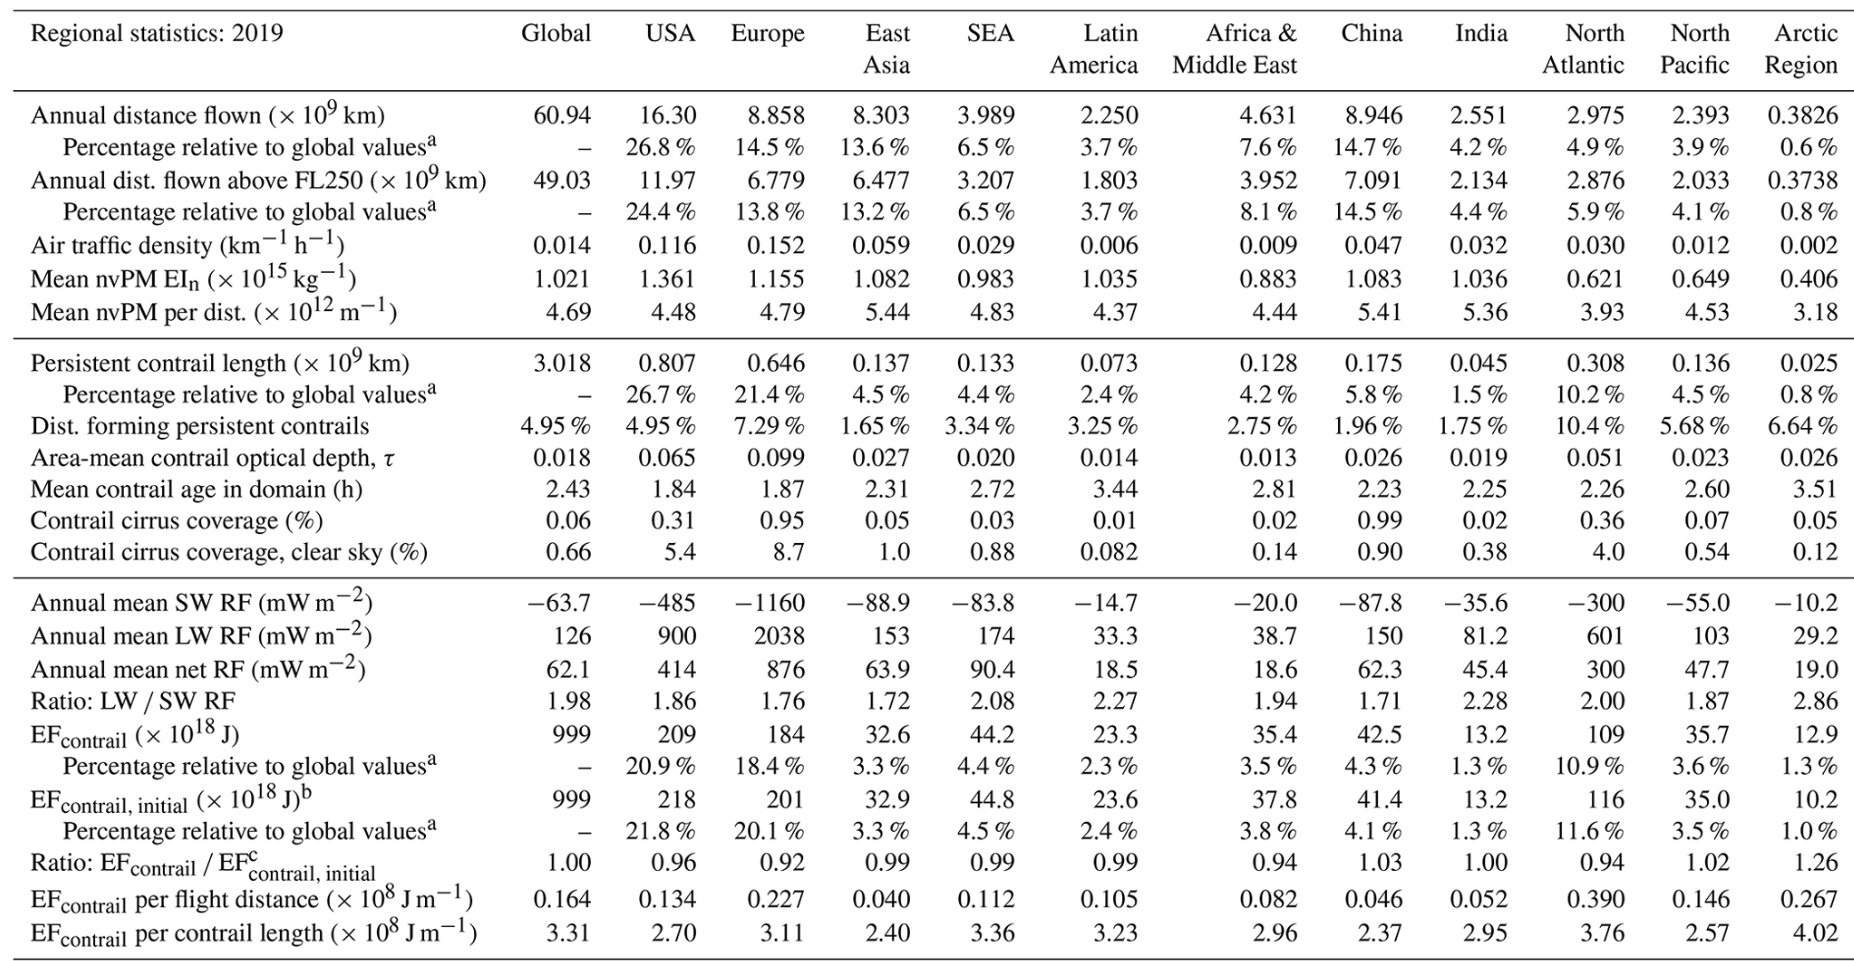

### Compute statistics using parquet approach 2

In [2]:
import pandas as pd
import geopandas as gpd


# These hourly totals are obtained by directly summing the parquet files without the grid
# This should be less prone to bugs in the code than the above approach and give better results
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region.pq")

df_region_sums = df.groupby("region").sum(numeric_only=True).reset_index()



# Load airspace geometry to get information about Eurocontrol airspaces back
airspaces = gpd.read_file("data/airspaces.geojson")
air_attr = airspaces[["name", "Eurocontrol FIR", "type"]]
df_merged = df_region_sums.merge(
    air_attr,
    how="left",
    left_on="region",
    right_on="name"
).drop(columns="name")


df_merged.to_csv("output/forcing/3_statistics.csv", index=False)


df_merged[df_merged["region"] == "Global"]

,region,hour,total_flight_dist,contrail_ef_initial_loc,contrail_ef_overlap_initial_loc,new_contrail_length,total_contrail_length,tau_contrail_area,mean_contrail_age,contrail_ef,contrail_ef_sw,contrail_ef_lw,contrail_ef_overlap,contrail_ef_sw_overlap,contrail_ef_lw_overlap,Eurocontrol FIR,type
87,Global,100740,6.085401e+13,8.294830e+20,7.716292e+20,3.227577e+12,1.148644e+13,1.127690e+16,1.539507e+09,8.298887e+20,-1.038676e+21,1.869836e+21,7.717040e+20,-9.690562e+20,1.749584e+21,None,RECT


In [3]:
df_merged[df_merged["region"] == "European Airspace"]

,region,hour,total_flight_dist,contrail_ef_initial_loc,contrail_ef_overlap_initial_loc,new_contrail_length,total_contrail_length,tau_contrail_area,mean_contrail_age,contrail_ef,contrail_ef_sw,contrail_ef_lw,contrail_ef_overlap,contrail_ef_sw_overlap,contrail_ef_lw_overlap,Eurocontrol FIR,type
80,European Airspace,99360,1.296607e+13,2.547200e+20,2.304492e+20,9.861705e+11,3.446090e+12,3.377313e+15,4.060757e+08,2.496942e+20,-3.624458e+20,6.124649e+20,2.260104e+20,-3.222316e+20,5.486033e+20,None,RECT


### Do these results make sense? 

The netcdf method 1 gives 779e18 J and the parquet summation method 2 gives 772e18 J. After some in-depth testing, I believe that  there are disk errors when reading the parquet files. Sometimes, the daily or hourly files will just contain zeros. Anyway, the correct number is 779x10^18 J consistent between different experiments and Roger. There is a small mismatch between `hourly_totals_by_region.pq` and the correct value (probably a small number of files read incorrectly), but I deem it acceptable since the error is below 1% and there is no systematic trend (e.g. only Mondays missing) according to my tests. 

Do these results make sense? 
Roger Teoh wrote me the following: 
```
 These results are from a more recent (yet to be published) simulations using pycontrails v0.54.8 without vPM activation, and the contrail RF is around 20% lower than those in the publication. We have to share this more recent dataset, rather than the publication, because the gridded outputs have a much higher spatiotemporal resolution. 
```

2019 contrail RF is 779e18 J versus 999e18 J for 2019. This is roughly 20% lower and matches Roger's description.

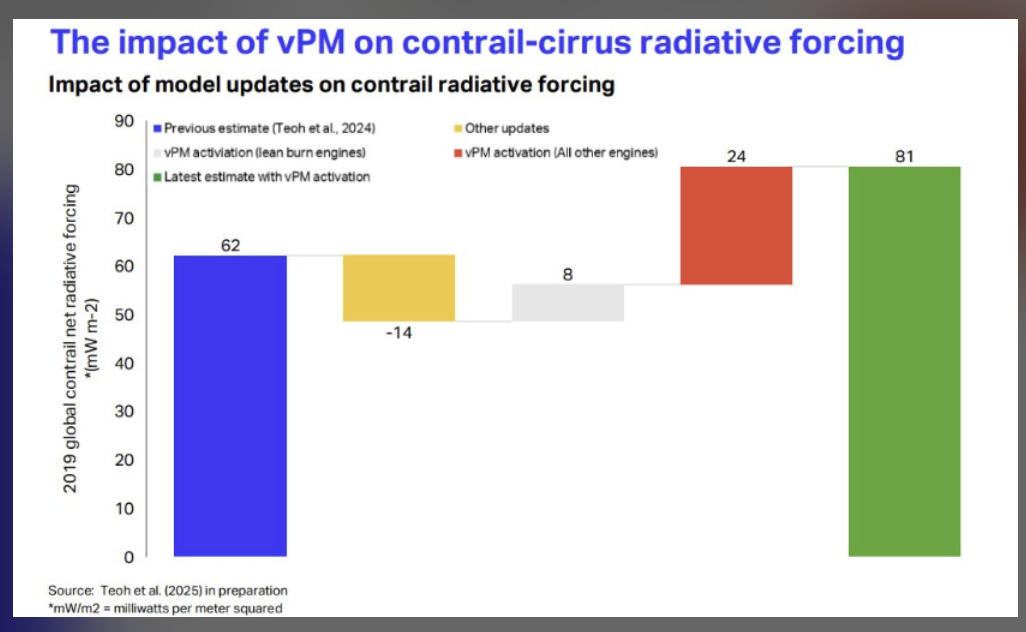

In [22]:
def joule_to_mW_per_m2(E):
    R = 6371                           # km, Earth average radius
    A = 4 * 3.1415 * R * R * 1e6       # Earth surface in m^2
    W = E / (365 * 24 * 60 * 60) * 1e3 # Annual radiation work in mW
    return W/A                         # forcing in mW/m^2 

f1 = joule_to_mW_per_m2(E = 999e18) # Annual energy forcing in J from Roger's publication
f2 = joule_to_mW_per_m2(E = 779e18) # Annual energy forcing in J from Roger's publication
f1, f2, f1-14                       # The 778e18 J figure closely matches this figure

(62.10786720404258, 48.43045901096013, 48.10786720404258)

## 4. European Maps (used in report)

In [50]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

OUTDIR = "aggregated"

def plot_map(ds, var="seg_length_km", vmin=None, vmax=None, extent=[-70, 45, 25, 60], savepath=None):
    """
    Plot a 2D map of the given variable from an xarray Dataset.
    Assumes dimensions: (flight_level, latitude, longitude).
    Sums over flight levels before plotting.
    """
    # --- Sum over altitude / flight levels ---
    if var == "forcing_per_dist": 
        data_2d_forcing = ds["contrail_ef_overlap_initial_loc"].squeeze()
        data_2d_dist    = ds["total_flight_dist"     ].squeeze()
        data_2d         = xr.where(data_2d_dist != 0, data_2d_forcing / data_2d_dist, 0)
    else: 
        data_2d = ds[var].squeeze()

    lon = ds.longitude.values
    lat = ds.latitude.values

    proj = ccrs.AlbersEqualArea(
        central_longitude=0,  # Center of map horizontally
        central_latitude=30,  # Center vertically
        standard_parallels=(20, 40)  # Choose parallels around your region of interest
    )

    # --- Setup map ---
    fig, ax = plt.subplots(
        subplot_kw={"projection": proj},
        figsize=(7.94*2, 5.75*2)
    )

    # Pick the right viewing window
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="white")
    ax.add_feature(cfeature.OCEAN, facecolor="white")

    # --- Plot data ---
    im = ax.imshow(
        data_2d,
        origin="lower",
        cmap="gist_heat_r",
        transform=ccrs.PlateCarree(),
        extent=[lon.min(), lon.max(), lat.min(), lat.max()],
        vmin=vmin,
        vmax=vmax
    )   
    
    plt.axis('off')


    # --- Save to PNG ---
    if savepath:
        plt.savefig(savepath, bbox_inches="tight", pad_inches=0)


    
    plt.show()

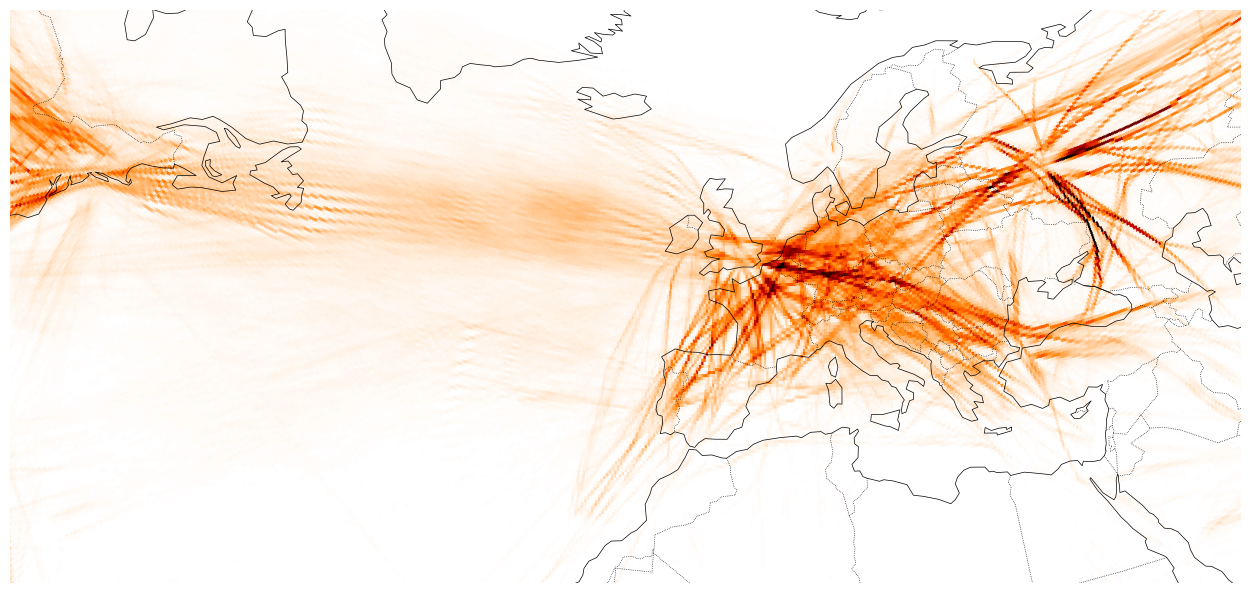

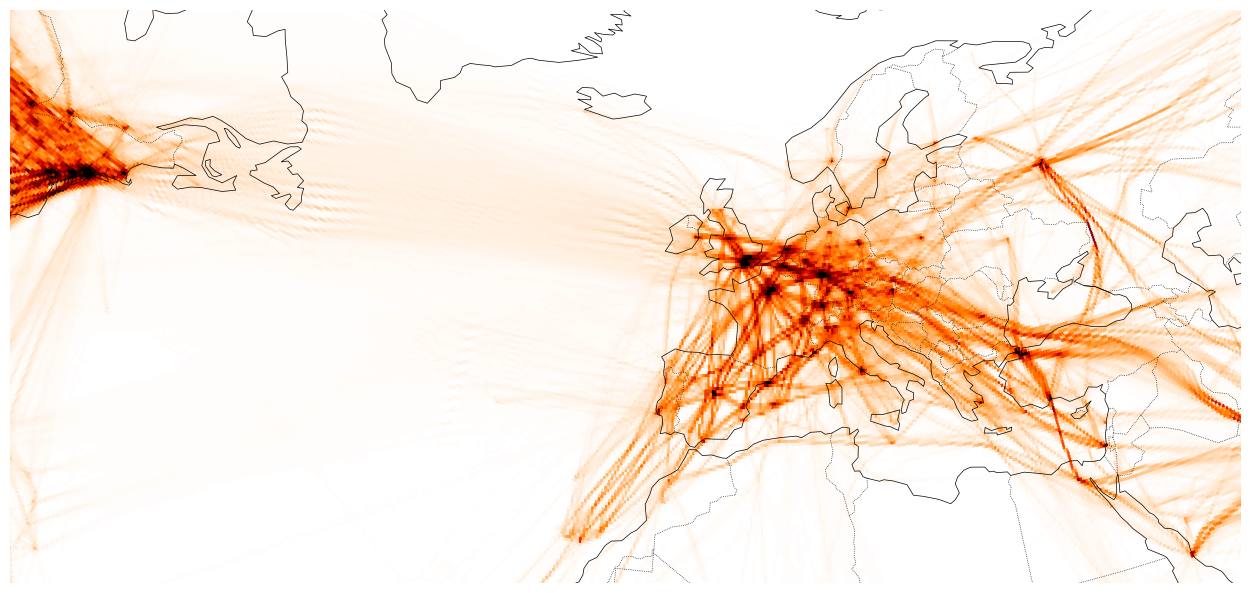

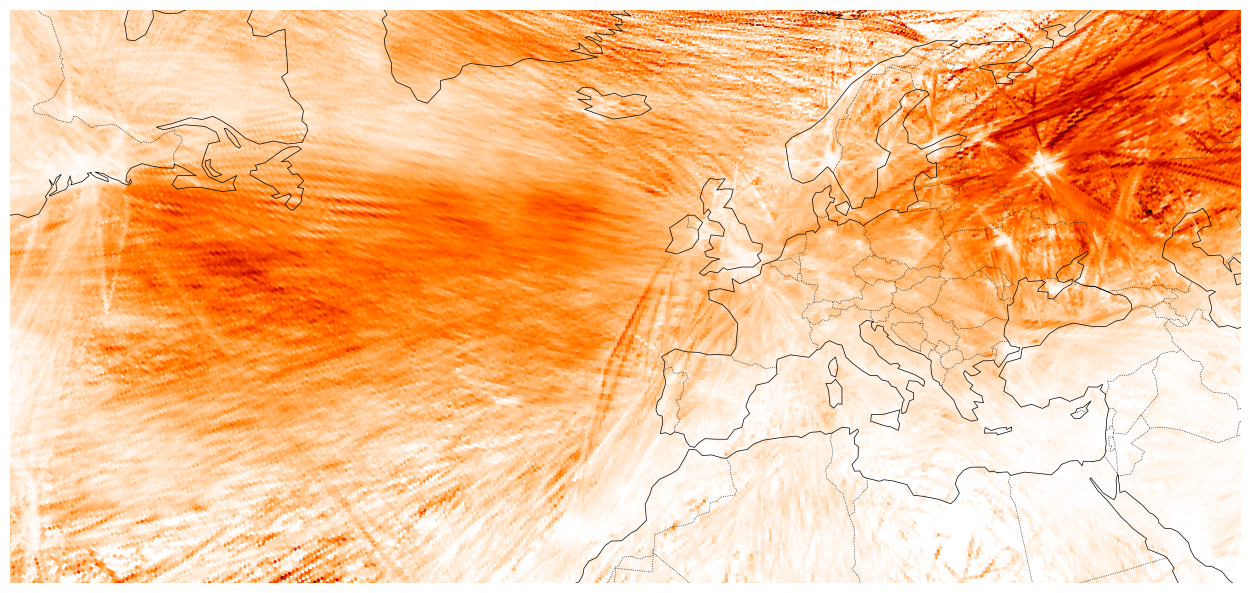

In [59]:
import xarray as xr 
ds = xr.open_dataset("data/gridded_forcing/annual_sum_2d.nc")

# Here I have a cutoff for flight dist and contrail warming since otherwise, a handful of points would dominate the colour scheme. 
plot_map(ds, var="contrail_ef_overlap_initial_loc", vmin=0,      vmax = 1e17,savepath="output/forcing/4_eurocontrol_warming_map.png")
plot_map(ds, var="total_flight_dist",               vmin=0,      vmax = 5e9, savepath="output/forcing/4_eurocontrol_flight_distance_map.png")
plot_map(ds, var="forcing_per_dist",                vmin=0,      vmax = 2e8, savepath="output/forcing/4_eurocontrol_warming_per_flight_distance_map.png")

### Calculate key quantities for the map

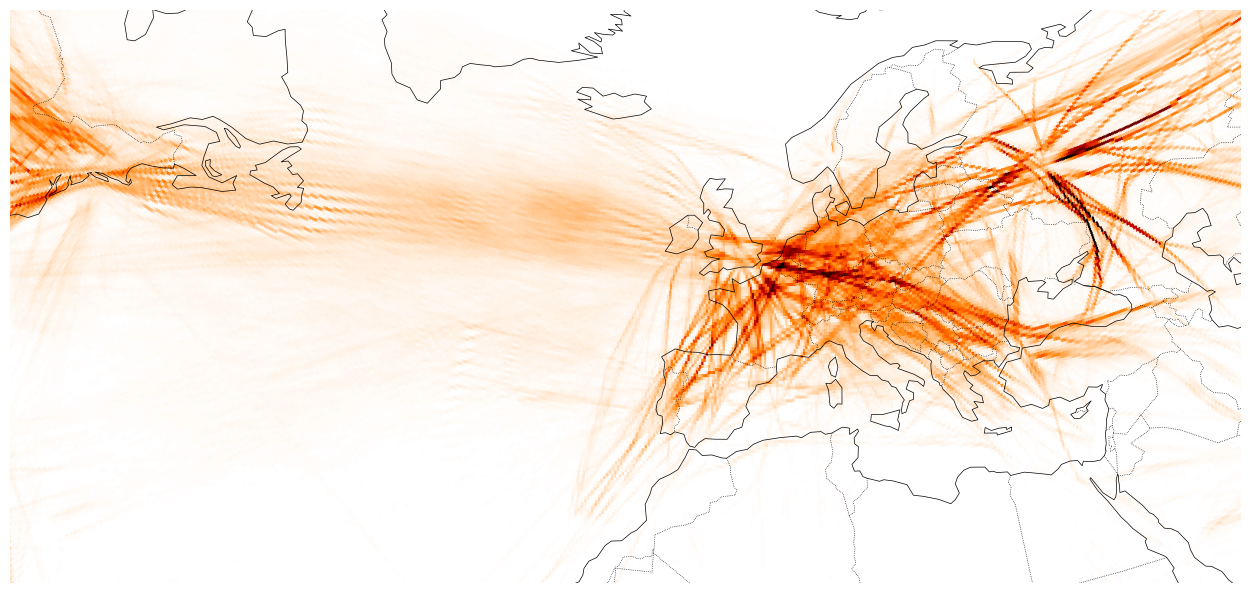

In [ ]:

# Here I have a cutoff for flight dist and contrail warming since otherwise, a handful of points would dominate the colour scheme. 
plot_map(ds, var="contrail_ef_overlap_initial_loc", vmin=0, vmax = 1e17, extent = [-70, 45, 25, 60])

In [10]:
ds_subset = ds.sel(
    longitude=slice(-70, 45),
    latitude=slice(25, 60)
)

traffic_share  = ds_subset["total_flight_dist"].sum()               / ds["total_flight_dist"].sum()
contrail_share = ds_subset["contrail_ef_overlap_initial_loc"].sum() / ds["contrail_ef_overlap_initial_loc"].sum()

traffic_share, contrail_share

(<xarray.DataArray 'total_flight_dist' ()> Size: 4B
 array(0.2606894, dtype=float32),
 <xarray.DataArray 'contrail_ef_overlap_initial_loc' ()> Size: 4B
 array(0.43998906, dtype=float32))

The maps approximately cover 25% of global traffic and 45% of global contrail warming. 

### Key quantities for continental Europe

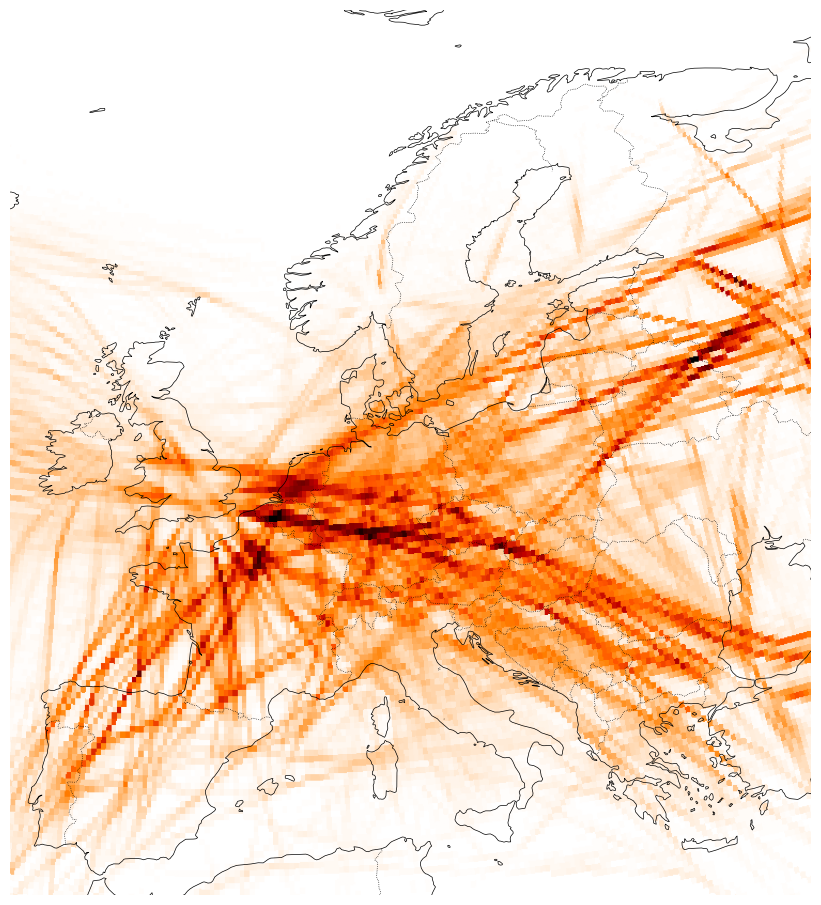

In [44]:

# Here I have a cutoff for flight dist and contrail warming since otherwise, a handful of points would dominate the colour scheme. 
plot_map(ds, var="contrail_ef_overlap_initial_loc", vmin=0, vmax = 1e17, extent = [-10, 30, 35, 75])

In [45]:
ds_subset = ds.sel(
    longitude=slice(-10, 30),
    latitude=slice(35, 75)
)

traffic_share  = ds_subset["total_flight_dist"].sum()               / ds["total_flight_dist"].sum()
contrail_share = ds_subset["contrail_ef_overlap_initial_loc"].sum() / ds["contrail_ef_overlap_initial_loc"].sum()

traffic_share, contrail_share

(<xarray.DataArray 'total_flight_dist' ()> Size: 4B
 array(0.17195614, dtype=float32),
 <xarray.DataArray 'contrail_ef_overlap_initial_loc' ()> Size: 4B
 array(0.23949614, dtype=float32))

Continental Europe covers 14% of global traffic and 18% of global contrail warming. 

### Key quantities over the North Atlantic

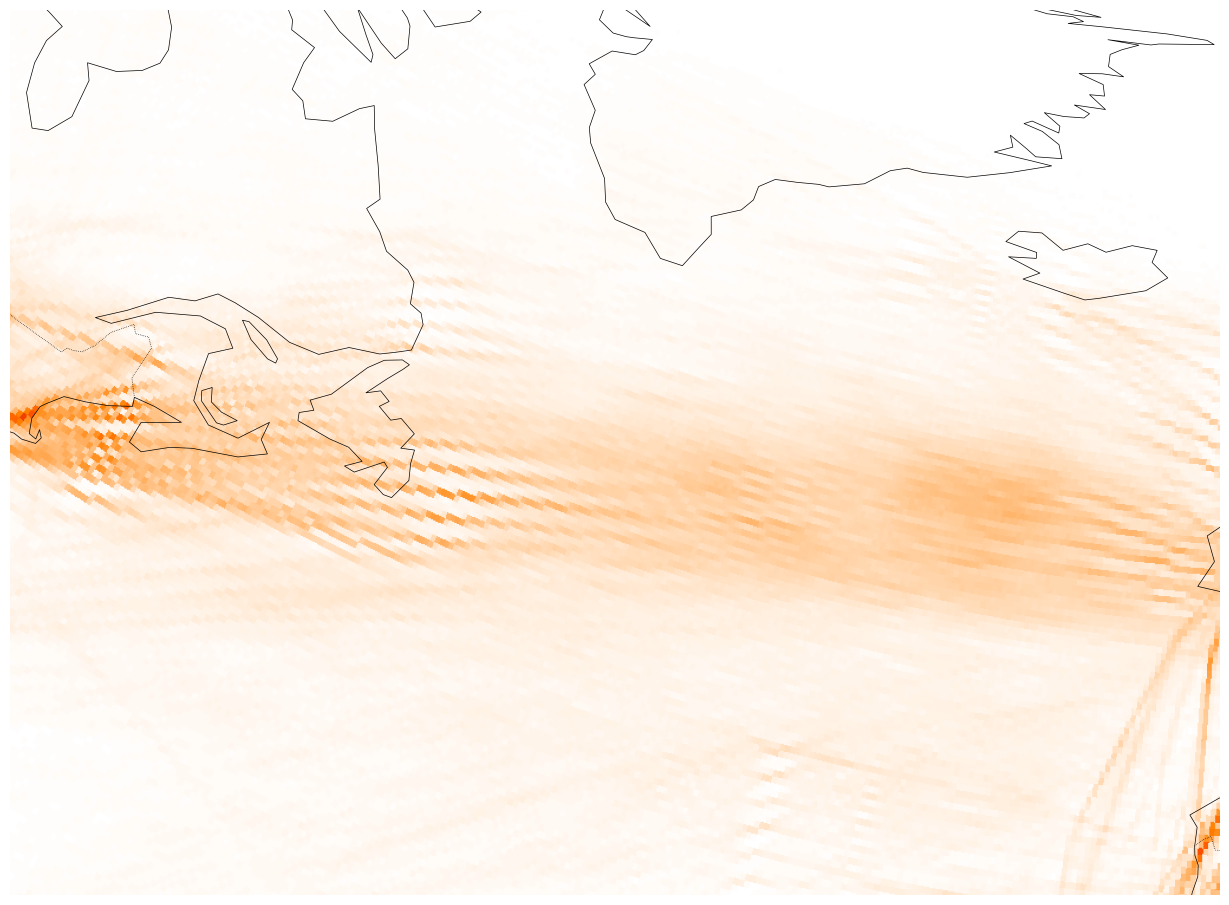

In [43]:

# Here I have a cutoff for flight dist and contrail warming since otherwise, a handful of points would dominate the colour scheme. 
plot_map(ds, var="contrail_ef_overlap_initial_loc", vmin=0, vmax = 1e17, extent = [-70, -10, 40, 63])

In [46]:
ds_subset = ds.sel(
    longitude=slice(-70, -10),
    latitude=slice(40, 63)
)

traffic_share  = ds_subset["total_flight_dist"].sum()               / ds["total_flight_dist"].sum()
contrail_share = ds_subset["contrail_ef_overlap_initial_loc"].sum() / ds["contrail_ef_overlap_initial_loc"].sum()

ds_subset["total_flight_dist"].sum() , ds_subset["contrail_ef_overlap_initial_loc"].sum(), traffic_share, contrail_share

(<xarray.DataArray 'total_flight_dist' ()> Size: 4B
 array(2.326991e+12, dtype=float32),
 <xarray.DataArray 'contrail_ef_overlap_initial_loc' ()> Size: 4B
 array(8.449508e+19, dtype=float32),
 <xarray.DataArray 'total_flight_dist' ()> Size: 4B
 array(0.03823591, dtype=float32),
 <xarray.DataArray 'contrail_ef_overlap_initial_loc' ()> Size: 4B
 array(0.11393537, dtype=float32))

## 5. Traffic by flight level (used in report)

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd#
import geopandas as gpd
import regionmask


def make_fl_bands(fl_step=10, fl_min=200, fl_max=500):
    """
    Generate a dictionary of flight level bands in meters.

    Parameters
    ----------
    fl_step : int
        Step size in flight levels (hundreds of feet), e.g. 25 = 2500 ft.
    fl_max : int
        Maximum flight level (hundreds of feet), e.g. 500 = 50,000 ft.

    Returns
    -------
    dict
        Keys: band labels (e.g. 'FL000–025'), 
        Values: (lower_alt_m, upper_alt_m) tuples.
    """
    ft_to_m = 0.3048  # 1 ft = 0.3048 m
    fl_bands = {}
    for fl in range(fl_min, fl_max, fl_step):

        label = f"FL{fl:03d}"
        fl_bands[label] = ((fl - fl_step/2)* 100 * ft_to_m, (fl + fl_step/2) * 100 * ft_to_m)
    return fl_bands

def aggregate_by_flight_level(ds, var="total_flight_dist"):
    # --- Define finer flight level bands (in meters) ---
    fl_bands = make_fl_bands()

    # --- Sum horizontally first ---
    var_sum = ds[var].sum(dim=["longitude", "latitude"])
    alt = ds["altitude"]

    # --- Aggregate per band ---
    var_agg = []
    labels = []

    for fl_label, (zmin, zmax) in fl_bands.items():
        mask = (alt >= zmin) & (alt < zmax)
        if mask.any():
            var_band = var_sum.where(mask, drop=True).sum()
            var_agg.append(var_band.item())
            labels.append(fl_label)

    return labels, np.array(var_agg)

def subset_region(ds, region_polygon):
    """
    Clip an xarray dataset to a region polygon.
    """
    mask = regionmask.Regions([region_polygon])
    
    # Apply masking
    mask_xr = mask.mask(ds["longitude"], ds["latitude"])

    # Region 0 → keep where mask_xr == 0
    return ds.where(mask_xr == 0, drop=True)

def aggregate_region(ds, region_name, region_polygon, var1="total_flight_dist", var2="contrail_ef_overlap_initial_loc"):
    """
    Subset a dataset to a region polygon and compute FL aggregates.
    Returns a dataframe with a 'region' column.
    """
    # subset grid
    ds_region = subset_region(ds, region_polygon)

    # aggregate
    fl, v1 = aggregate_by_flight_level(ds_region, var=var1)
    _,  v2 = aggregate_by_flight_level(ds_region, var=var2)


    # build output df
    df = pd.DataFrame({
        "Flight level":                 fl,
        r"Flight distance":             v1 / dist_normalisation,
        r"Contrail warming":            v2 / warming_normalisation,
        r"Warming per flight distance": v2 / v1 / warming_per_dist_normalisation,
        "Region":                       region_name,
    })

    return df

ds = xr.open_dataset("data/gridded_forcing/annual_sum_from_pq.nc")

ds = ds.drop_sel(longitude=180)

gdf_combined = gpd.read_file("data/airspaces.geojson").set_crs(epsg=4326)

combined_mask = regionmask.Regions(
    outlines=gdf_combined.geometry.values,
    names=gdf_combined["name"].tolist(),
    abbrevs=gdf_combined["name"].tolist(),
)


all_dfs = []

for rid, rname in enumerate(combined_mask.names):
    print(f"Processing region: {rname}")
    geom = combined_mask[rid].polygon
    df_reg = aggregate_region(ds, rname, geom)
    all_dfs.append(df_reg)

df_all = pd.concat(all_dfs, ignore_index=True)
df_all.to_csv("output/forcing/5_forcing_by_flight_level.csv", index=False)
df_all


Processing region: European Airspace
Processing region: North Atlantic
Processing region: Continental Europe
Processing region: Global
Processing region: USA
Processing region: East Asia
Processing region: Southeast Asia
Processing region: Latin America
Processing region: Africa & Middle East
Processing region: China
Processing region: India
Processing region: North Pacific
Processing region: Arctic
Processing region: Honiara FIR


C:\Users\TE\AppData\Local\Temp\ipykernel_7332\760270037.py:85: RuntimeWarning: invalid value encountered in divide
  r"Warming per flight distance": v2 / v1 / warming_per_dist_normalisation,


Processing region: Nauru FIR


C:\Users\TE\AppData\Local\Temp\ipykernel_7332\760270037.py:85: RuntimeWarning: invalid value encountered in divide
  r"Warming per flight distance": v2 / v1 / warming_per_dist_normalisation,


Processing region: Port Moresby FIR


...

Processing region: Lanzhou FIR
Processing region: Ulaanbaatar FIR
Processing region: Kunming FIR
Processing region: Shanghai FIR
Processing region: Urumqi FIR


C:\Users\TE\AppData\Local\Temp\ipykernel_7332\760270037.py:85: RuntimeWarning: invalid value encountered in divide
  r"Warming per flight distance": v2 / v1 / warming_per_dist_normalisation,


Processing region: Shenyang FIR


C:\Users\TE\AppData\Local\Temp\ipykernel_7332\760270037.py:85: RuntimeWarning: invalid value encountered in divide
  r"Warming per flight distance": v2 / v1 / warming_per_dist_normalisation,


,Flight level,Flight distance,Contrail warming,Warming per flight distance,Region
0,FL200,8.811909e-03,0.000000e+00,0.000000e+00,European Airspace
1,FL210,9.010218e-03,-8.686583e-07,-9.640814e-05,European Airspace
2,FL220,9.307233e-03,1.095346e-05,1.176876e-03,European Airspace
3,FL230,1.081468e-02,7.766702e-05,7.181627e-03,European Airspace
4,FL240,1.161706e-02,1.701174e-04,1.464375e-02,European Airspace
...,...,...,...,...,...
8035,FL450,2.442655e-06,-5.521574e-13,-2.260480e-07,Shenyang FIR
8036,FL460,3.203775e-07,0.000000e+00,0.000000e+00,Shenyang FIR
8037,FL470,1.602382e-06,0.000000e+00,0.000000e+00,Shenyang FIR
8038,FL480,1.282877e-07,0.000000e+00,0.000000e+00,Shenyang FIR


![image.png](figures\2_forcing\forcing_5_by_flight_level@2x.png)

## 6. Forcing by hour (used in report)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region.pq")

# Ensure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Compute hourly aggregates
df_hourly = (
    df
    .groupby(["region", df["timestamp"].dt.hour.rename("hour")], sort=False)
    .agg({
        "total_flight_dist": "sum",
        "contrail_ef_overlap_initial_loc": "sum"
    })
    .reset_index()
)

df = pd.DataFrame({
    "Hour":                         df_hourly["hour"], 
    r"Flight distance":             df_hourly["total_flight_dist"]/dist_normalisation, 
    r"Contrail warming":            df_hourly["contrail_ef_overlap_initial_loc"]/warming_normalisation, 
    r"Warming per flight distance": df_hourly["contrail_ef_overlap_initial_loc"]/df_hourly["total_flight_dist"]/warming_per_dist_normalisation,
    "Region":                       df_hourly["region"]
    }).round(8)



# Sort each region block by shifted hour order, preserving overall region order
df = (
    df.groupby("Region", group_keys=False, sort=False)
      .apply(lambda g: g.sort_values("Hour", key=lambda x: (x - 6) % 24))
      .reset_index(drop=True)
)

# Save 
df.to_csv("output/forcing/6_forcing_by_hour.csv", index=False)

df

C:\Users\TE\AppData\Local\Temp\ipykernel_7332\2045503055.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values("Hour", key=lambda x: (x - 6) % 24))


,Hour,Flight distance,Contrail warming,Warming per flight distance,Region
0,6,0.037161,0.010408,0.280077,European Airspace
1,7,0.046147,0.003561,0.077171,European Airspace
2,8,0.050782,-0.001512,-0.029768,European Airspace
3,9,0.054269,-0.002994,-0.055161,European Airspace
4,10,0.057850,-0.001696,-0.029316,European Airspace
...,...,...,...,...,...
6427,1,0.001081,-0.000823,-0.761090,Shenyang FIR
6428,2,0.001186,-0.000858,-0.723291,Shenyang FIR
6429,3,0.001183,-0.000681,-0.575764,Shenyang FIR
6430,4,0.001262,-0.000529,-0.419044,Shenyang FIR


![image.png](figures\6.png)

## 7. Forcing by month (used in report)

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region.pq")

month_map = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}

# Ensure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Compute monthly aggregates
df_monthly = (
    df
    .groupby([df["region"], df["timestamp"].dt.to_period("M")], sort=False)
    .agg({
        "total_flight_dist": "sum",
        "contrail_ef_overlap_initial_loc": "sum"
    })
    .reset_index()
)

# Convert period to timestamp for plotting
df_monthly["timestamp"] = df_monthly["timestamp"].dt.to_timestamp()


df = pd.DataFrame({
    "Month":                        df_monthly["timestamp"].dt.month.map(month_map), 
    "Flight distance":              df_monthly["total_flight_dist"]/dist_normalisation, 
    "Contrail warming":             df_monthly["contrail_ef_overlap_initial_loc"]/warming_normalisation,
    "Warming per flight distance ": df_monthly["contrail_ef_overlap_initial_loc"]/df_monthly["total_flight_dist"]/warming_per_dist_normalisation,
    "Region":                       df_monthly["region"]
    }).round(8)

df.to_csv("output/forcing/7_forcing_by_month.csv", index=False)

df

,Month,Flight distance,Contrail warming,Warming per flight distance,Region
0,Jan,0.069167,0.124412,1.798721,European Airspace
1,Jan,0.016172,0.062296,3.852134,North Atlantic
2,Jan,0.045539,0.059368,1.303682,Continental Europe
3,Jan,0.368748,0.396120,1.074229,Global
4,Jan,0.090915,0.052721,0.579889,USA
...,...,...,...,...,...
3211,Dec,0.001049,0.001663,1.585447,Ulaanbaatar FIR
3212,Dec,0.005227,0.000153,0.029235,Kunming FIR
3213,Dec,0.011289,0.001059,0.093850,Shanghai FIR
3214,Dec,0.001008,0.001995,1.978502,Urumqi FIR


![image.png](figures\7.png)

## 8. Forcing in winter nights (used in report)


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region.pq")

df = df[df["region"] == "European Airspace"]
# Ensure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Compute hourly aggregates
df_hourly = (
    df
    .groupby([df["timestamp"].dt.to_period("M"), df["timestamp"].dt.hour.rename("hour")], sort=True)
    .agg({
        "total_flight_dist": "sum",
        "contrail_ef_overlap_initial_loc": "sum"
    })
    .reset_index()
)


month_map = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}


df = pd.DataFrame({
    "Month":                       df_hourly["timestamp"].dt.month.map(month_map), 
    "Hour":                        df_hourly["hour"], 
    "Flight distance":             df_hourly["total_flight_dist"]/dist_normalisation, 
    "Contrail warming":            df_hourly["contrail_ef_overlap_initial_loc"]/warming_normalisation, 
    "Warming per flight distance": df_hourly["contrail_ef_overlap_initial_loc"]/df_hourly["total_flight_dist"]/warming_per_dist_normalisation
    }).round(8)
# Save 
df.to_csv("output/forcing/6_7_forcing_by_month_and_hour.csv", index=False)

df

,Month,Hour,Flight distance,Contrail warming,Warming per flight distance
0,Jan,0,0.000237,0.000950,4.006080
1,Jan,1,0.000161,0.000697,4.327574
2,Jan,2,0.000160,0.000605,3.791663
3,Jan,3,0.000204,0.000731,3.588290
4,Jan,4,0.000271,0.001121,4.137142
...,...,...,...,...,...
283,Dec,19,0.000759,0.002898,3.817950
284,Dec,20,0.000680,0.002563,3.768920
285,Dec,21,0.000635,0.002284,3.597273
286,Dec,22,0.000507,0.001799,3.544682


: 

In [ ]:
import matplotlib.pyplot as plt

plt.plot()

This is only used to assess which share of contrail warming happens in winter nights. 

In [127]:
import pandas as pd

# Load the dataframe
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region.pq")

# Ensure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Extract time components
df["month"] = df["timestamp"].dt.month
df["hour"] = df["timestamp"].dt.hour

# Define winter months and night hours
winter_months = [10, 11, 12, 1, 2, 3]    # Oct–Mar
# Night = 20–23 and 0–4
night_hours = list(range(20, 24)) + list(range(0, 5))

# Compute annual totals per region
annual = df.groupby("region").agg(
    annual_traffic=("total_flight_dist", "sum"),
    annual_warming=("contrail_ef_overlap_initial_loc", "sum")
).reset_index()

# Filter winter + night
df_winter_night = df[
    df["month"].isin(winter_months) &
    df["hour"].isin(night_hours)
]

# Compute winter-night totals per region
winter_night = df_winter_night.groupby("region").agg(
    wn_traffic=("total_flight_dist", "sum"),
    wn_warming=("contrail_ef_overlap_initial_loc", "sum")
).reset_index()

# Merge with annual totals
merged = annual.merge(winter_night, on="region", how="left")

# Compute shares
merged["traffic_share"] = merged["wn_traffic"] / merged["annual_traffic"]
merged["warming_share"] = merged["wn_warming"] / merged["annual_warming"]

# Final output table
result = merged[["region", "traffic_share", "warming_share"]].fillna(0)

# Save if desired
result.to_csv("output/winter_night_shares_by_region.csv", index=False)

result


,region,traffic_share,warming_share
0,Accra FIR,0.144884,0.389278
1,Addis Abeba FIR,0.258685,0.141811
2,Africa & Middle East,0.148618,0.387434
3,Aktobe FIR,0.234529,0.326344
4,Alaska FIR,0.190851,0.146484
...,...,...,...
263,Yakutsk FIR,0.180305,0.187883
264,Yangon FIR,0.210440,0.111320
265,Yekaterinburg FIR,0.224091,0.348390
266,Yerevan FIR,0.200664,0.385992


In [129]:
import pandas as pd

# Load the dataframe
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region.pq")

# Ensure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Extract time components
df["month"] = df["timestamp"].dt.month
df["hour"] = df["timestamp"].dt.hour

# Define winter months and night hours
winter_months = [10, 11, 12, 1, 2, 3]    # Oct–Mar
# Night = 20–23 and 0–4
night_hours = list(range(20, 24)) + list(range(0, 5))

# Compute annual totals per region
annual = df.groupby("region").agg(
    annual_traffic=("total_flight_dist", "sum"),
    annual_warming=("contrail_ef_overlap_initial_loc", "sum")
).reset_index()

# Filter winter + night
df_winter_night = df[
    #df["month"].isin(winter_months) &
    df["hour"].isin(night_hours)
]

# Compute winter-night totals per region
winter_night = df_winter_night.groupby("region").agg(
    wn_traffic=("total_flight_dist", "sum"),
    wn_warming=("contrail_ef_overlap_initial_loc", "sum")
).reset_index()

# Merge with annual totals
merged = annual.merge(winter_night, on="region", how="left")

# Compute shares
merged["traffic_share"] = merged["wn_traffic"] / merged["annual_traffic"]
merged["warming_share"] = merged["wn_warming"] / merged["annual_warming"]

# Final output table
result = merged[["region", "traffic_share", "warming_share"]].fillna(0)

# Save if desired
result.to_csv("output/winter_night_shares_by_region.csv", index=False)

result


,region,traffic_share,warming_share
0,Accra FIR,0.371568,0.788638
1,Addis Abeba FIR,0.516844,0.599730
2,Africa & Middle East,0.330589,0.630750
3,Aktobe FIR,0.437595,0.361456
4,Alaska FIR,0.416853,0.194374
...,...,...,...
263,Yakutsk FIR,0.410187,0.160231
264,Yangon FIR,0.395506,0.368130
265,Yekaterinburg FIR,0.477382,0.419091
266,Yerevan FIR,0.386989,0.478269


## 9. Forcing by FIR (maybe used in report)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas

# Load the dataframe
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region.pq")

# Compute monthly aggregates
df_fir = (
    df
    .groupby("region")
    .agg({
        "total_flight_dist": "sum",
        "contrail_ef_overlap_initial_loc": "sum"
    })
    .reset_index()
)

# --- Load airspace geometries ---
airspaces = gpd.read_file("data/airspaces.geojson")

# Filter European FIRs and compute surface area in km²
eu_airspaces = airspaces[airspaces["Eurocontrol FIR"] == "True"].copy()

# ✅ Reproject to an equal-area CRS for Europe (EPSG:3035 = ETRS89 / LAEA Europe)
eu_airspaces = eu_airspaces.to_crs(epsg=3035)

eu_airspaces["surface_km2"] = eu_airspaces.geometry.area / 1e6  # from m² to km²

# Create a list of tuples (FIR name, surface area)
eu_firs = list(zip(eu_airspaces["name"], eu_airspaces["surface_km2"]))

# --- Filter df_fir to include only EU FIRs ---
df_fir = df_fir[df_fir["region"].isin(eu_airspaces["name"])]

# Merge FIR data with geometries to get surface area in dataframe
df_fir = df_fir.merge(
    eu_airspaces[["name", "surface_km2"]],
    left_on="region",
    right_on="name",
    how="left"
)

# --- Create the output dataframe ---
df = pd.DataFrame({
    "Flight Information Region (FIR)": df_fir["region"],
    "Surface area": df_fir["surface_km2"] / area_normalisation,
    "Contrail warming": df_fir["contrail_ef_overlap_initial_loc"] / warming_normalisation,
    "Flown distance": df_fir["total_flight_dist"] / dist_normalisation,
    "Contrail warming per flown distance": (
        df_fir["contrail_ef_overlap_initial_loc"] / df_fir["total_flight_dist"] / warming_per_dist_normalisation
    ),
    # New density metrics
    "Contrail warming density": (
        df_fir["contrail_ef_overlap_initial_loc"] / df_fir["surface_km2"] / (warming_normalisation / area_normalisation)
    ),
    "Flown distance density": (
        df_fir["total_flight_dist"] / df_fir["surface_km2"] / (dist_normalisation / area_normalisation)
    )
}).round(5)

# --- Save to CSV ---
df.to_csv("output/forcing/8_forcing_by_fir.csv", index=False)

![image.png](figures\2_forcing\forcing_8_by_fir@2x.png)

![ContrailOpp](figures\2_forcing\forcing_11_low_traffic@2x.png)

## 10. How busy is airspace when contrails occur? (used in report)

100.0


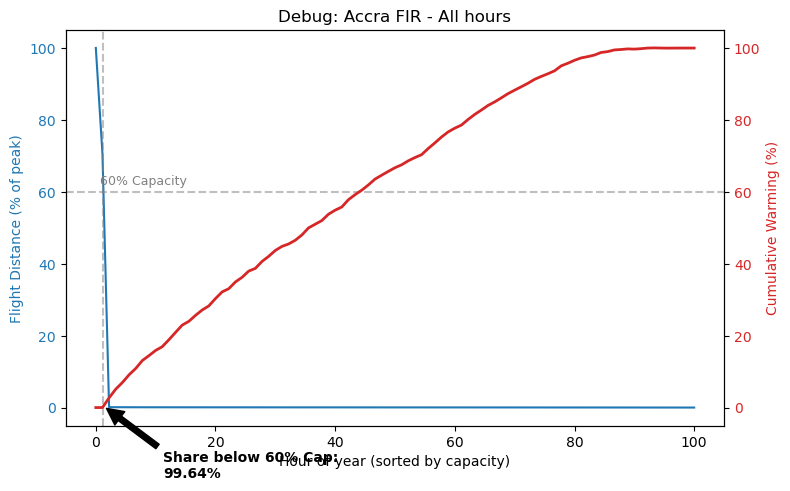

90.4534


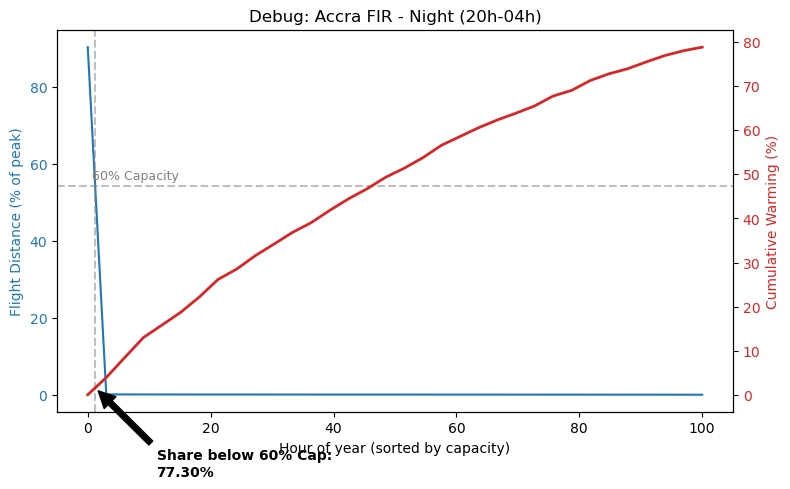

84.144


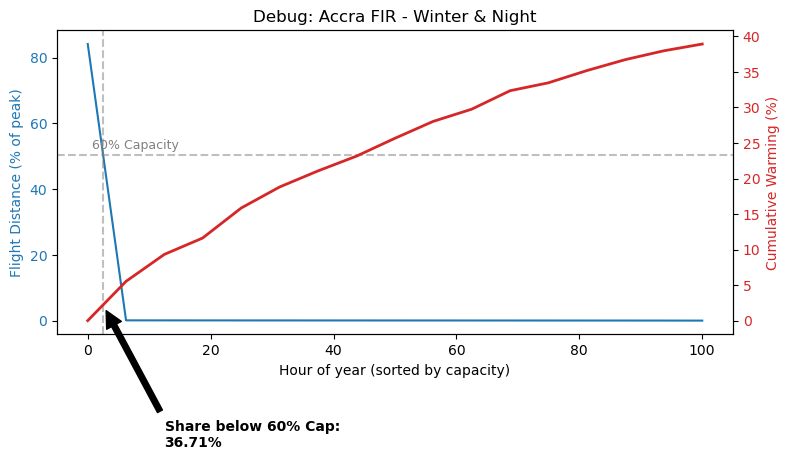

89.6364


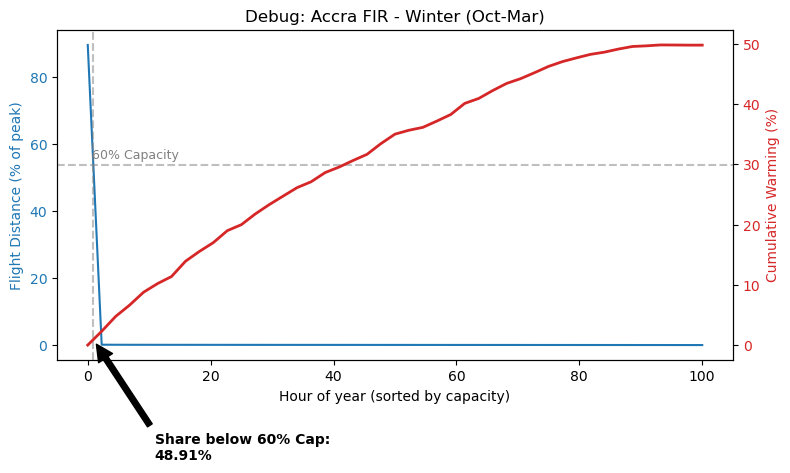

100.0


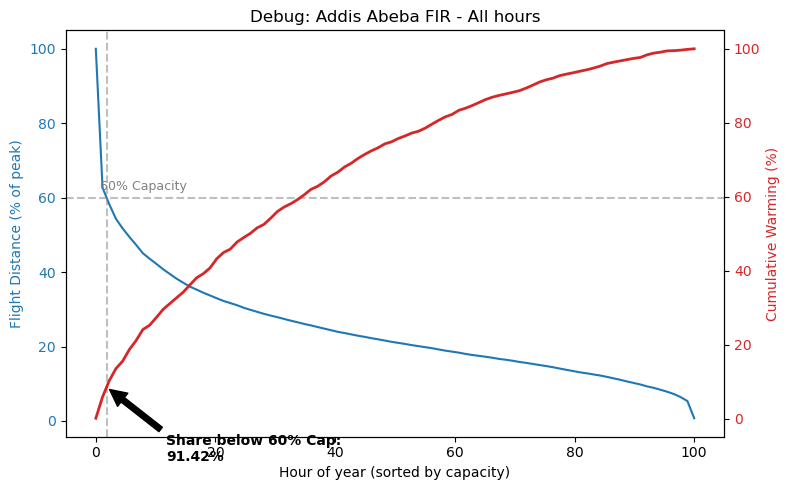

100.0
90.1719
90.1719
100.0
90.4534
84.144
89.6364
100.0
100.0
100.0
100.0
100.0
91.9203
84.4278
100.0
100.0
88.0733
88.0733
100.0
100.0
100.0
100.0
100.0
100.0
100.0
94.5171
96.4473
100.0
89.843
89.843
100.0
100.0
80.9502
57.3457
70.1372
100.0
100.0
88.0301
98.8151
100.0
97.1631
97.1631
97.1631
100.0
67.5537
66.5613
100.0
100.0
97.2746
97.2746
100.0
100.0
65.6599
61.0524
74.9786
100.0
58.4546
58.4546
100.0
100.0
100.0
100.0
100.0
100.0
100.0
96.0476
96.0476
100.0
68.8634
57.6208
89.6483
100.0
80.4165
75.0566
97.869
100.0
100.0
91.8928
95.181
100.0
62.0152
62.0152
100.0
100.0
100.0
100.0
100.0
100.0
100.0
100.0
100.0
100.0
100.0
100.0
100.0
100.0
100.0
100.0
100.0
100.0
82.2249
82.2249
100.0
100.0
82.553
71.7372
93.0082
100.0
90.2952
79.4784
100.0
100.0
100.0
100.0
100.0
100.0
65.1479
56.9883
93.4662
100.0
87.0796
66.8375
83.9654
100.0
69.5507
59.2253
100.0
100.0
91.1834
91.1834
100.0
100.0
37.5641
37.5641
92.6069
100.0
100.0
92.3315
92.3315
100.0
100.0
67.6083
84.4739
100.0
100.0
76.5

C:\Users\TE\AppData\Local\Temp\ipykernel_18260\426250089.py:191: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_share_below_60)


✅ Final Summary exported to output/forcing/10_warming_shares_below_60pct_by_region.csv
Subset         Region  All hours  Winter (Oct-Mar)  Night (20h-04h)  \
10      Amsterdam FIR  47.800822         36.006987        28.423077   
11         Ankara FIR  74.079541         60.417850        44.178647   
19        Athinai FIR  89.934552         70.012865        36.557631   
27      Barcelona FIR  84.139779         48.254496        54.795785   
32        Beograd FIR  91.540755         63.320430        27.639148   

Subset  Winter & Night  
10           17.097918  
11           36.218991  
19           21.898306  
27           28.479444  
32           15.289143  


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import geopandas as gpd
# Load your data
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region.pq")

# Parse timestamps
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["month"] = df["timestamp"].dt.month
df["hour"] = df["timestamp"].dt.hour

# Function to compute cumulative and percent values for one region
def compute_region_metrics(df_region, tot_heating, max_flight_dist):
    df_sorted = df_region.sort_values("total_flight_dist", ascending=False).reset_index(drop=True)
    
    df_sorted["cum_flight"]      = df_sorted["total_flight_dist"].cumsum()
    df_sorted["cum_heating"]     = df_sorted["contrail_ef_overlap_initial_loc"].cumsum()
    df_sorted["cum_heating_pct"] = df_sorted["cum_heating"] / tot_heating * 100
    df_sorted["tot_flight_pct"]  = df_sorted["total_flight_dist"] / max_flight_dist * 100
    df_sorted["block_pct"]       = np.linspace(0, 100, len(df_sorted))
    N = len(df_sorted) // 96
    idx = np.linspace(0, len(df_sorted) - 1, N, dtype=int)

    df_vis = (
        df_sorted[["region", "block_pct", "tot_flight_pct", "cum_heating_pct"]]
        .iloc[idx]
        .rename(columns={
            "region":          "Region",
            "block_pct":       "Hour of year",
            "tot_flight_pct":  "Flight distance",
            "cum_heating_pct": "Cumulative contrail warming"
        })
    )
    return df_vis



results = []
for region, df_region in df.groupby("region", sort=False):

    # Compute maximum values in region for normalisation 
    tot_heating     = df_region["contrail_ef_overlap_initial_loc"].sum()
    max_flight_dist = df_region["total_flight_dist"].max()

    # Define filters
    is_winter = df_region["month"].isin([10, 11, 12, 1, 2, 3])
    is_night = df_region["hour"].isin([20, 21, 22, 23, 0, 1, 2, 3, 4])
    is_winter_night = is_winter & is_night

    subsets = [
        (df_region, "All hours"),
        (df_region[is_winter], "Winter (Oct-Mar)"),
        (df_region[is_night], "Night (20h-04h)"),
        (df_region[is_winter_night], "Winter & Night"),
    ]

    for subset_df, label in subsets:
        df_region_out = compute_region_metrics(subset_df, tot_heating, max_flight_dist)
        df_region_out["Subset"] = label
        results.append(df_region_out)

all_results =  pd.concat(results, ignore_index=True).round(4)

# Export to CSV
output_path = "output/forcing/9_cum_heating_vs_business_with_seasonal_blocks.csv"
all_results.to_csv(output_path, index=False)


# Compute share below 60% capacity in wide format
# ------------------------------------------------------------------

# Initialize a global counter for debug plots
debug_counter = 0

def get_share_below_60(df_subset):
    """
    Interpolates the cumulative warming percentage when 
    Flight distance (capacity) is at 60%.
    Includes a debug plot for the first 5 calls.
    """
    global debug_counter
    
    # 1. Sort by x-axis (Flight distance) for valid interpolation
    df_sorted = df_subset#.sort_values("Flight distance")
    
    # --- Step 1: Find the Hour where Capacity = 60% ---
    # We interpolate Flight Distance vs Hour. 
    # Since Flight Distance is descending, we flip it for np.interp (needs increasing x)
    # x = Flight Distance (flipped), y = Hour (flipped to match)
    cutoff_hour = np.interp(
        60, 
        df_sorted["Flight distance"].values[::-1], 
        df_sorted["Hour of year"].values[::-1]
    )

    warming_at_cutoff = np.interp(
        cutoff_hour,
        df_sorted["Hour of year"],
        df_sorted["Cumulative contrail warming"]
    )
    import matplotlib.pyplot as plt

# Initialize a global counter for debug plots
debug_counter = 0

def get_share_below_60(df_subset):
    """
    1. Finds the 'Hour of year' where Flight distance drops to 60%.
    2. Finds the 'Cumulative warming' at that specific hour.
    3. Calculates the warming occurring AFTER that hour (the share below 60%).
    """
    global debug_counter
    
    # Ensure data is sorted by Hour of year (0 -> 100)
    # Note: Logic assumes Flight Distance decreases as Hour increases
    df_sorted = df_subset.sort_values("Hour of year").reset_index(drop=True)
    
    # --- Step 1: Find the Hour where Capacity = 60% of peak ---
    # We interpolate Flight Distance vs Hour. 
    # Since Flight Distance is descending, we flip it for np.interp (needs increasing x)
    # x = Flight Distance (flipped), y = Hour (flipped to match)
    print(df_sorted["Flight distance"].max())
    cutoff_hour = np.interp(
        60 * df_sorted["Flight distance"].max()/100, 
        df_sorted["Flight distance"].values[::-1], 
        df_sorted["Hour of year"].values[::-1]
    )
    
    # --- Step 2: Find Cumulative Warming at that Cutoff Hour ---
    # x = Hour, y = Cumulative Warming
    warming_at_cutoff = np.interp(
        cutoff_hour,
        df_sorted["Hour of year"],
        df_sorted["Cumulative contrail warming"]
    )
    
    # --- Step 3: Calculate Share Below 60% ---
    # The 'warming_at_cutoff' is the warming generated by the high-traffic hours.
    # The remainder is the warming generated by the low-traffic (<60%) hours.
    max_warming = df_sorted["Cumulative contrail warming"].max() # Should be ~100
    share_below_60 = max_warming - warming_at_cutoff
    
# --- Debug Plotting (First 5 only) ---
    if debug_counter < 5:
        region_name = df_sorted["Region"].iloc[0] if "Region" in df_sorted.columns else "Region"
        subset_name = df_sorted["Subset"].iloc[0] if "Subset" in df_sorted.columns else "Subset"
        
        fig, ax1 = plt.subplots(figsize=(8, 5))
        
        # Plot 1: Flight Distance (Capacity)
        color = 'tab:blue'
        ax1.set_xlabel('Hour of year (sorted by capacity)')
        ax1.set_ylabel('Flight Distance (% of peak)', color=color)
        ax1.plot(df_sorted["Hour of year"], df_sorted["Flight distance"], color=color, label="Capacity")
        ax1.tick_params(axis='y', labelcolor=color)
        
        # Mark the 60% capacity threshold
        ax1.axhline(60 * df_sorted["Flight distance"].max()/100, color="gray", linestyle="--", alpha=0.5)
        ax1.axvline(cutoff_hour, color="gray", linestyle="--", alpha=0.5)
        ax1.text(0, 62 * df_sorted["Flight distance"].max()/100, " 60% Capacity", color="gray", fontsize=9)
        
        # Plot 2: Cumulative Warming
        ax2 = ax1.twinx()  
        color = 'tab:red'
        ax2.set_ylabel('Cumulative Warming (%)', color=color)  
        ax2.plot(df_sorted["Hour of year"], df_sorted["Cumulative contrail warming"], color=color, linewidth=2, label="Cum. Warming")
        ax2.tick_params(axis='y', labelcolor=color)
        
        # Highlight the "Below 60%" portion
        # The share is the vertical distance from the intersection to the top (100%)
        ax2.annotate(
            f'Share below 60% Cap:\n{share_below_60:.2f}%',
            xy=(cutoff_hour, warming_at_cutoff), 
            xytext=(cutoff_hour + 10, warming_at_cutoff - 20),
            arrowprops=dict(facecolor='black', shrink=0.05),
            fontsize=10, fontweight='bold'
        )
        
        plt.title(f"Debug: {region_name} - {subset_name}")
        fig.tight_layout()
        plt.show()
        
        debug_counter += 1
        
    return share_below_60

# 1. Group by Region and Subset, then apply calculation
summary_long = (
    all_results.groupby(["Region", "Subset"])
    .apply(get_share_below_60)
    .reset_index(name="Share below 60% of peak traffic")
)

# 2. Pivot to get Subsets as columns
summary_wide = summary_long.pivot(
    index="Region", 
    columns="Subset", 
    values="Share below 60% of peak traffic"
)

# 3. Reorder columns to ensure logical progression (optional but recommended)
desired_order = ["All hours", "Winter (Oct-Mar)", "Night (20h-04h)", "Winter & Night"]
# Only select columns that actually exist in the data (in case some subsets were empty)
existing_cols = [c for c in desired_order if c in summary_wide.columns]
summary_wide = summary_wide[existing_cols].reset_index()

# ------------------------------------------------------------------
# FILTERING: Filter for EU Airspaces
# ------------------------------------------------------------------

airspaces = gpd.read_file("data/airspaces.geojson")
eu_airspaces = airspaces[airspaces["Eurocontrol FIR"] == "True"].copy()

# Filter summary to include only EU FIRs
summary_final = summary_wide[summary_wide["Region"].isin(eu_airspaces["name"])].copy()

# Export final wide-format CSV
final_output_path = "output/forcing/10_warming_shares_below_60pct_by_region.csv"
summary_final.to_csv(final_output_path, index=False)

print(f"✅ Final Summary exported to {final_output_path}")
print(summary_final.head())

![image.png](figures\2_forcing\forcing_9_how_busy_are_airspaces@2x.png)

In [119]:
all_results

,Region,Hour of year,Flight distance,Cumulative contrail warming,Subset
0,European Airspace,0.0000,100.000000,0.0136,All hours
1,European Airspace,1.1228,87.298302,-0.1622,All hours
2,European Airspace,2.2456,84.405800,-0.1761,All hours
3,European Airspace,3.3684,82.476898,-0.1290,All hours
4,European Airspace,4.4913,80.941299,-0.0692,All hours
...,...,...,...,...,...
48543,Shenyang FIR,73.3169,9.773500,-29.0300,Winter & Night
48544,Shenyang FIR,79.9876,8.417000,-28.9634,Winter & Night
48545,Shenyang FIR,86.6584,7.057500,-28.8590,Winter & Night
48546,Shenyang FIR,93.3292,5.712500,-28.8631,Winter & Night


## 11. Will it keep controllers busy all day? (used in report)

In [116]:
import pandas as pd
import numpy as np
import geopandas 

# Load your data
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region.pq")

# Function to compute cumulative and percent values for one region
def compute_region_metrics(df_region):
    df_sorted = df_region.sort_values("contrail_ef_overlap_initial_loc", ascending=False).reset_index(drop=True)
    
    df_sorted["cum_flight"]      = df_sorted["total_flight_dist"].cumsum()
    df_sorted["cum_heating"]     = df_sorted["contrail_ef_overlap_initial_loc"].cumsum()
    df_sorted["cum_heating_pct"] = df_sorted["cum_heating"] / df_sorted["cum_heating"].iloc[-1] * 100
    df_sorted["block_pct"] = np.linspace(0, 100, len(df_sorted))

    # I want roughly hundred samples out of the year's 365 * 24 = 8760 hours.
    # So, ideally I would like to sample every 3.65 * 24 hours 
    # Rounding up to 4, I get a sampling frequency of 4 * 24 = 96.
    sample_freq = 96
    N = len(df_sorted) // sample_freq
    idx = np.linspace(0, len(df_sorted) - 1, N, dtype=int)

    # Final dataframe with visualization-friendly column names
    df_vis = (
        df_sorted[["region", "block_pct", "cum_heating_pct"]]
        .iloc[idx]
        .rename(columns={
            "region":          "Region",
            "block_pct":       "Hour of year",
            "cum_heating_pct": "Cumulative contrail warming"
        })
    )

    return df_vis

# Apply to each region and concatenate results
results = []
for region, df_region in df.groupby("region", sort=False):
    region_df = compute_region_metrics(df_region)
    results.append(region_df)

df_all_regions = pd.concat(results, ignore_index=True).round(4)

# Export to CSV
output_path = "output/forcing/11_cum_heating.csv"
df_all_regions.to_csv(output_path, index=False)

print(f"✅ CSV exported to {output_path}")


# Function to compute the share of hours needed to reach 80% of cumulative warming
def compute_hours_to_80pct(region_df):
    df_sorted = region_df.sort_values("Hour of year").reset_index(drop=True)
    
    # Interpolate to find the hour of year where warming reaches 80%
    idx = (df_sorted["Cumulative contrail warming"] >= 80).idxmax()

    return pd.Series({
        "Share of year to reach 80% warming (%)": df_sorted.loc[idx, "Hour of year"]
    })

# Apply by region
summary = df_all_regions.groupby("Region").apply(compute_hours_to_80pct).reset_index()

# --- Load airspace geometries ---
airspaces = gpd.read_file("data/airspaces.geojson")

# Filter European FIRs and compute surface area in km²
eu_airspaces = airspaces[airspaces["Eurocontrol FIR"] == "True"].copy()

# --- Filter df_fir to include only EU FIRs ---
summary = summary[summary["Region"].isin(eu_airspaces["name"])]

output_path = "output/forcing/12_hours_to_80pct_warming.csv"
summary.to_csv(output_path, index=False)


print(f"✅ CSV exported to {output_path}")

✅ CSV exported to output/forcing/11_cum_heating.csv


C:\Users\TE\AppData\Local\Temp\ipykernel_22116\865071746.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df_all_regions.groupby("Region").apply(compute_hours_to_80pct).reset_index()


✅ CSV exported to output/forcing/12_hours_to_80pct_warming.csv


![ContrailConcentration](figures\2_forcing\forcing_10_contrail_concentration@2x.png)

![ContrailOpp2](figures\2_forcing\forcing_12_low_load@2x.png)

## 12. Create forcing calendar (used in report)

In [14]:
import pandas as pd

# Load the dataframe
df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region.pq")

# Select relevant columns and regions
df_s = df[["timestamp", "contrail_ef_overlap_initial_loc", "region"]]
df_s = df_s[df_s["region"].isin(["Global", "European Airspace", "Paris FIR", "London FIR", "Switzerland FIR", "Shanwick FIR"])]

# Convert to correct scale
df_s["contrail_ef_overlap_initial_loc"] /= warming_normalisation

# Convert timestamp to datetime if not already
df_s["timestamp"] = pd.to_datetime(df_s["timestamp"])

# Create a date column (without time)
df_s["date"] = df_s["timestamp"].dt.date

# Sum all hourly values by day and region
df_daily = (
    df_s.groupby(["date", "region"], as_index=False)
        .agg({"contrail_ef_overlap_initial_loc": "sum"})
        .round(7)
)

# Save to CSV
df_daily.to_csv("output/forcing/13_forcing_calendar_daily.csv", index=False)


![ForcingCalendar](figures\2_forcing\forcing_13_big_hits_per_day_fir@2x.png)

In [15]:

df = pd.read_parquet("data/gridded_forcing/hourly_totals_by_region.pq")


In [18]:
df_ = df[df["file"] == "20190325.pq"]

In [21]:
print(df_)

        hour  total_flight_dist  contrail_ef_initial_loc  \
527270     0       6.054190e+09             9.483290e+16   
527271     1       6.748619e+09             1.548169e+17   
527272     2       6.734067e+09             1.532035e+17   
527273     3       6.539091e+09             1.423748e+17   
527274     4       6.129868e+09             1.048632e+17   
...      ...                ...                      ...   
527337    19       6.910836e+09             8.192699e+16   
527338    20       6.810362e+09             7.643362e+16   
527339    21       6.737991e+09             6.886803e+16   
527340    22       6.322170e+09             7.296131e+16   
527341    23       6.009896e+09             8.316641e+16   

        contrail_ef_overlap_initial_loc  new_contrail_length  \
527270                              0.0          337573504.0   
527271                              0.0          368014848.0   
527272                              0.0          359926656.0   
527273                 

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import regionmask
import glob, re
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

# ---------------------------------------
# CONFIGURATION
# ---------------------------------------

COLS_SUM = [
    "total_flight_dist",
    "contrail_ef_initial_loc",
    "contrail_ef_overlap_initial_loc",
    "new_contrail_length",
    "total_contrail_length",
    "tau_contrail_area",
    "mean_contrail_age",
    "contrail_ef",
    "contrail_ef_sw",
    "contrail_ef_lw",
    "contrail_ef_overlap",
    "contrail_ef_sw_overlap",
    "contrail_ef_lw_overlap",
]

TARGET_REGIONS = [
    "Global",
    "European Airspace",
    "Paris FIR",
    "London FIR",
    "Switzerland FIR",
    "Shanwick FIR",
]

MISSING_FOLDER = "data\gridded_forcing\missing"
OUTPUT_FILE = Path("hourly_totals_by_region.pq")
N_WORKERS = 4


# ---------------------------------------
# REGION MASK
# ---------------------------------------

def build_regionmask():
    gdf = gpd.read_file("airspaces.geojson").set_crs(epsg=4326)

    return regionmask.Regions(
        outlines=gdf.geometry.values,
        names=gdf["name"].tolist(),
        abbrevs=gdf["name"].tolist(),
    )


# ---------------------------------------
# FILE PROCESSING
# ---------------------------------------

def process_file(file, mask):
    fname = Path(file).stem
    m = re.search(r"(\d{8})", fname)
    if not m:
        raise ValueError(f"Unsupported filename: {fname}")

    date = pd.Timestamp(m.group(1))

    df = pd.read_parquet(file).fillna(0)
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
        crs="EPSG:4326",
    )

    results = []

    for region_id, region_name in enumerate(mask.names):
        if region_name not in TARGET_REGIONS:
            continue

        geom = mask[region_id].polygon
        minx, miny, maxx, maxy = geom.bounds

        subset = gdf.cx[minx:maxx, miny:maxy]
        subset = subset[subset.geometry.within(geom)]

        if subset.empty:
            continue

        df_hourly = (
            subset.groupby("hour")[COLS_SUM]
            .sum(min_count=1)
            .reset_index()
        )

        df_hourly["timestamp"] = [
            date + pd.Timedelta(hours=int(h))
            for h in df_hourly["hour"]
        ]
        df_hourly["region"] = region_name
        df_hourly["file"] = Path(file).name

        results.append(df_hourly)

    return pd.concat(results, ignore_index=True) if results else None


# ---------------------------------------
# MAIN
# ---------------------------------------

def main():
    pq_files = sorted(glob.glob(f"{MISSING_FOLDER}/*.pq"))

    if not pq_files:
        print("❌ No parquet files found in ./missing")
        return

    print(f"Found {len(pq_files)} missing-day parquet files")

    mask = build_regionmask()
    results = []

    with ProcessPoolExecutor(max_workers=N_WORKERS) as executor:
        futures = {
            executor.submit(process_file, f, mask): f
            for f in pq_files
        }

        for fut in tqdm(as_completed(futures), total=len(futures)):
            df_res = fut.result()
            if df_res is not None:
                results.append(df_res)

    if not results:
        print("❌ No new data generated")
        return

    df_new = pd.concat(results, ignore_index=True)

    print(
        "Recomputed date range:",
        df_new["timestamp"].min(),
        "→",
        df_new["timestamp"].max(),
    )

    # -----------------------------------
    # SURGICAL UPDATE
    # -----------------------------------

    df_existing = pd.read_parquet(OUTPUT_FILE)

    df_existing["_key"] = (
        df_existing["timestamp"].astype(str)
        + "|"
        + df_existing["region"]
    )
    df_new["_key"] = (
        df_new["timestamp"].astype(str)
        + "|"
        + df_new["region"]
    )

    df_existing_clean = df_existing[
        ~df_existing["_key"].isin(df_new["_key"])
    ]

    df_updated = pd.concat(
        [
            df_existing_clean.drop(columns="_key"),
            df_new.drop(columns="_key"),
        ],
        ignore_index=True,
    ).sort_values(["timestamp", "region"])

    df_updated.to_parquet(OUTPUT_FILE, index=False)

    print(
        f"✅ Successfully patched {OUTPUT_FILE} "
        f"with {len(df_new)} rows"
    )


if __name__ == "__main__":
    main()
